## Load the dataset and create the medium

In [6]:
import cobra
model = cobra.io.load_json_model("H:/ROBOT_SCIENTIST/E_coli/iML1515.json")
model

Name,iML1515
Memory address,1cec7e4a3c8
Number of metabolites,1877
Number of reactions,2712
Number of genes,1516
Number of groups,0
Objective expression,1.0*BIOMASS_Ec_iML1515_core_75p37M - 1.0*BIOMASS_Ec_iML1515_core_75p37M_reverse_35685
Compartments,"cytosol, extracellular space, periplasm"


### All of the follwoing analysis happens in the function 'run'. For each strain or experiment, first it fits a line on all datapoints and reports the estimated $R^2$. Then, repeat the analysis for subsets of data. The subsets are categoriesd based on the supplements class: "sugars", "nucleobases", "amino acides", "sugars + nucleobases", and ""sugars + nucleobases  + amino acides"

In [7]:
import cobra
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from pathlib import Path

def run(per_strain: bool = True,
        strain:str = "WT",
        replication:str = "no_replicates",
        gr_column:str = "mv_mu_max",
        experiment:str = "mediabotJLF2",
        well_column: str = "well",
        od_cv_mean_threshold: float = 0.0,
        od_cv_max_threshold: float = 0.0,
        od_std_max_threshold: float = 0.0,
        ):
    model = cobra.io.load_json_model("H:/ROBOT_SCIENTIST/E_coli/iML1515.json")
    
    flg_has_statistic = True
    if per_strain:
        exp_data_path = f"H:/ROBOT_SCIENTIST/E_coli/Growth_rates/2025-10-31-27/processed/{replication}_STRAINS/{strain}/AMN_dataset/"
        growth_data_path = f"H:/ROBOT_SCIENTIST/E_coli/Growth_rates/2025-10-31-27/processed/{replication}_STRAINS/{strain}/" 
        std_data_path = f"H:/ROBOT_SCIENTIST/E_coli/Growth_rates/2025-10-31-27/processed/{replication}/"
        directories = [d for d in Path(std_data_path).iterdir()]
        std_data_list = [ pd.read_csv(d / "predictions.csv") for d in directories if (d / "predictions.csv").exists() ]        
        for df , d in zip(std_data_list, directories):
            if "od600_mean" not in df.columns:
                flg_has_statistic = False
                break
            df["experiment"] = d.name
            # Coefficient of Variation (CV), also known as Relative Standard Deviation (RSD).
            df["od_CV"] = df['od600_std'] / df['od600_mean']

        if flg_has_statistic:
            std_data = pd.concat(std_data_list, ignore_index=True)        
            std_data = std_data.groupby([well_column,"experiment"]).agg(
                od_mean_max = ( 'od600_mean', 'max' ),
                od_mean_mean = ( 'od600_mean', 'mean' ),
                od_std_max = ( 'od600_std', 'max' ),
                od_std_mean = ( 'od600_std', 'mean' ),
                od_cv_max = ('od_CV', 'max'),
                od_cv_mean = ('od_CV', 'mean'),
            ).reset_index()  
        
        

    else:
        exp_data_path = f"H:/ROBOT_SCIENTIST/E_coli/Growth_rates/2025-10-31-27/processed/{replication}/{experiment}/AMN_dataset/"
        growth_data_path = f"H:/ROBOT_SCIENTIST/E_coli/Growth_rates/2025-10-31-27/processed/{replication}/{experiment}/"

        std_data = pd.read_csv(growth_data_path + "predictions.csv")        
        if "od600_mean" not in std_data.columns:
            flg_has_statistic = False
            std_data = std_data.groupby(well_column).agg(
                od_mean_max = ( 'od600_mean', 'max' ),
                od_mean_mean = ( 'od600_mean', 'mean' ),
                od_std_max = ( 'od600_std', 'max' ),
                od_std_mean = ( 'od600_std', 'mean' ),
            ).reset_index()
    # 
    exp_data = pd.read_csv(exp_data_path + "df_flux.csv") 
    growth_data = pd.read_csv(growth_data_path + "growth_rates.csv")
    
    # Filter growth_data to match the rows in exp_data 
    # Since exp_data was created from growth_data where success=='ok', we need to apply the same filter
    # OR simply take the first len(exp_data) rows if they're already aligned
    growth_data = growth_data.reset_index(drop=True)
    growth_data = growth_data.loc[growth_data['success'], :]
    exp_data = exp_data.reset_index(drop=True)        
    # Remove growth rate column from growth_data to avoid duplicates
    growth_data = growth_data.drop(columns=[gr_column])                
    # Now join them - they should have the same number of rows
    combinded_data = pd.concat([exp_data.reset_index(drop=True), growth_data.reset_index(drop=True)],
                                axis=1)
        
    if flg_has_statistic:
        if per_strain:
            combinded_data = combinded_data.merge(std_data, on=["experiment", well_column], how="left")
        else:
            combinded_data = combinded_data.merge(std_data, on=[well_column], how="left")

    if flg_has_statistic and od_cv_mean_threshold > 0.0:        
        combinded_data = combinded_data.loc[combinded_data["od_cv_mean"] <= od_cv_mean_threshold, :].copy().reset_index(drop=True)
        exp_data = combinded_data[exp_data.columns]
        if combinded_data.shape[0] < 2:
            print("Not enough data.")
            return
    elif flg_has_statistic and od_cv_max_threshold > 0.0:
        combinded_data = combinded_data.loc[combinded_data["od_cv_max"] <= od_cv_max_threshold, :].copy().reset_index(drop=True)
        exp_data = combinded_data[exp_data.columns]
        if combinded_data.shape[0] < 2:
            print("Not enough data.")
            return
    elif flg_has_statistic and od_std_max_threshold > 0.0:
        combinded_data = combinded_data.loc[combinded_data["od_std_max"] <= od_std_max_threshold, :].copy().reset_index(drop=True)
        exp_data = combinded_data[exp_data.columns]
        if combinded_data.shape[0] < 2:
            print("Not enough data.")
            return


    def update_uracil(val):
        for part in ["_0.5", "_22.4", "_200", "_2", "_8", "_64", "_640", "0"]:
             val = val.replace(part, "")
        return val
    combinded_data["supplements_unified"] = combinded_data["supplements"].apply(lambda x: update_uracil(str(x)) if pd.notna(x) else x)
    
    def classify(val):
        """Classify supplements into Sugar, Nucleo, Amino based on content"""
        if pd.isna(val) or str(val).lower() == 'nan' or str(val).strip() == '':
            return 'None'
        
        # Split by semicolon and convert to lowercase for comparison
        parts = str(val).lower().split(';')
        parts = [p.strip() for p in parts if p.strip()]
        
        if not parts:
            print(val)
            return 'None'
        
        # Define categories (all lowercase)
        sugars = ['glucose', 'succinate', 'sucrose', 'galactose', 'fructose', 'mannose',
                  'maltose', 'lactose', 'xylose', 'arabinose', 'ribose']
        
        nucleobases = ['adenine', 'uracil', 'guanine', 'cytosine', 'thymine']
        
        # Amino acids are typically 3 letters (all lowercase)
        amino_acids_3letter = ['ala', 'arg', 'asn', 'asp', 'cys', 'gln', 'glu', 'gly',
                               'his', 'ile', 'leu', 'lys', 'met', 'phe', 'pro', 'ser',
                               'thr', 'trp', 'tyr', 'val']
        
        categories = []
        for part in parts:
            # Check if it's a sugar
            if any(sugar in part for sugar in sugars):
                if 'Sugar' not in categories:
                    categories.append('Sugar')
            # Check if it's a nucleobase
            elif any(nucleo in part for nucleo in nucleobases):
                if 'Nucleo' not in categories:
                    categories.append('Nucleo')
            # Check if it's a 3-letter amino acid or contains common amino acid patterns
            elif any(aa in part for aa in amino_acids_3letter) or len(part) == 3:
                if 'Amino' not in categories:
                    categories.append('Amino')
        
        if not categories:
            return 'Other'
        
        # Sort to ensure consistent ordering
        categories.sort()
        return '+'.join(categories)
    
    combinded_data["group"] = combinded_data["supplements_unified"].apply(classify)
    #===============================
    preds = []
    status = []
    for _, row in exp_data.iterrows():
        with model:
            # Set the medium according to the experimental data
            medium = model.medium.copy()
            for rxn_id in medium:
                medium[rxn_id] = 0.0  # Set high uptake rates for all exchange reactions
            for rxn_id in exp_data.columns:
                if rxn_id != gr_column:
                    medium[rxn_id] = row.get(rxn_id, 0.0)  # Set uptake rates based on experimental data
            model.medium = medium
            # Perform FBA
            # model.objective = 'BIOMASS_Ec_iML1515_WT_75p37M'
            model.objective = 'BIOMASS_Ec_iML1515_core_75p37M'                
            solution = model.optimize()        
            preds.append(solution.objective_value)
            status.append(solution.status  == 'optimal')
            # if solution.status != 'optimal':
            #     print("=" * 40, "\n", f"faild solution \n{row}", "\n", "=" * 40)
    #
    # remove outtiers from predictions
    preds_array = np.array(preds)
    status_array = np.array(status)
    # Calculate Q1 (25th percentile) and Q3 (75th percentile)
    percentile_lower = 0#5
    percentile_upper = 100#75
    q1 = np.percentile(preds_array, percentile_lower)
    q3 = np.percentile(preds_array, percentile_upper)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    filtered_preds = [pred if lower_bound <= pred <= upper_bound else np.nan for pred in preds_array]
    filtered_status = [status_array[i] if lower_bound <= preds_array[i] <= upper_bound else False for i in range(len(preds_array))]
    #
    masks = [s for s in filtered_status]
    fig = plt.figure(figsize=(16,6))

    ax1, ax2, ax3 = fig.subplots(1,3)
    
    # Get filtered data for plotting
    y = np.array([p for p, m in zip(filtered_preds, masks) if m])
    x = np.array(combinded_data[gr_column][masks])

    # Get supplement groups for color coding
    groups = combinded_data['group'][masks].astype(str).values  
    unique_groups = np.unique(groups)
    n_groups = len(unique_groups)
    
    # Use a colormap with distinct colors
    if n_groups <= 10:
        colors = plt.cm.tab10(np.linspace(0, 1, 10))[:n_groups]
    elif n_groups <= 20:
        colors = plt.cm.tab20(np.linspace(0, 1, 20))[:n_groups]
    else:
        colors = plt.cm.gist_rainbow(np.linspace(0, 1, n_groups))
    
    # Create color map for supplements
    group_colors = {supp: colors[i] for i, supp in enumerate(unique_groups)}
    
    # Plot each supplement group with its own color
    for supp in unique_groups:
        supp_mask = groups == supp
        ax1.scatter(x[supp_mask], y[supp_mask], 
                   color=group_colors[supp], 
                   label=supp, 
                   alpha=0.7, 
                   s=50,
                   edgecolors='black',
                   linewidths=0.5)
    
    # Add legend
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, 
              title='Supplement', framealpha=0.9)
    m, b = np.polyfit(x, y, 1)
    ax1.plot(x, m*x + b, color='red', label=f'y={m:.2f}x+{b:.2f}')
    # find R2
    correlation_matrix = np.corrcoef(x, y)
    correlation_xy = correlation_matrix[0,1]
    r_squared = correlation_xy**2
    ax1.set_xlabel("Experimental growth rates")
    ax1.set_ylabel("FBA predicted growth rates")
    if per_strain:
        subtitle= (f"Strain:{strain}, "
                   f"\n Data points n:{sum(masks)}, Q1:%{percentile_lower}-Q2:%{percentile_upper}")
    else:
        subtitle= (f"experiment:{experiment},  "
                   f"\n Data points n:{sum(masks)}, Q1:%{percentile_lower}-Q2:%{percentile_upper}")
    ax1.set_title(f"(R²={r_squared:.4f}) \n"
              f"{subtitle}"
              )
    #==========================
    # residuals plots - also colored by supplement
    residuals = y - (m * x + b)
    for supp in unique_groups:
        supp_mask = groups == supp
        ax2.scatter(x[supp_mask], residuals[supp_mask], 
                   color=group_colors[supp], 
                   alpha=0.6,
                   s=50,
                   edgecolors='black',
                   linewidths=0.5)
    ax2.axhline(0, color='red', linestyle='--', linewidth=2)
    ax2.set_xlabel("Experimental growth rates")
    ax2.set_ylabel("Residuals (Predicted - Experimental)")
    ax2.set_title("Residuals Plot")
    #==========================
    # residual distribution: histogram with stacked by supplement
    # ax3.hist([residuals[groups == supp] for supp in unique_groups],
    #          label=[str(supp) for supp in unique_groups], # type: ignore
    #          color=[group_colors[supp] for supp in unique_groups], # type: ignore
    #          alpha=0.7,
    #          edgecolor='black',
    #          linewidth=0.5,
    #          stacked=False) # type: ignore
    ax3.hist(residuals,
             edgecolor='black',
             linewidth=0.5,
             stacked=False,
             ) # type: ignore
    ax3.legend(fontsize=8, title='Supplement')
    ax3.set_xlabel("Residuals")
    # rotate x tick labels
    ax3.tick_params(axis='x', rotation=45)    
    ax3.set_ylabel("Frequency")
    ax3.set_title("Residuals distribution.")
    #==========================

    average_type = "All data points" if replication == "no_replicates" else "OD average" if replication == "replicates" else "Growth rate average"
    plt.suptitle(f"Comparison of Experimental and FBA Predicted Growth Rates, replication:{average_type}")
    # plt.legend()
    plt.tight_layout()
    plt.show()

    #==========================
    # Create separate scatter plots for each supplement group with individual R²
    n_groups = len(unique_groups)
    n_cols = min(3, n_groups)
    n_rows = int(np.ceil(n_groups / n_cols))
    
    fig2, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
    if n_groups == 1:
        axes = np.array([axes])
    axes = axes.flatten() if n_groups > 1 else axes
    
    for idx, supp in enumerate(unique_groups):
        ax = axes[idx] if n_groups > 1 else axes[0]
        
        # Get data for this supplement group
        supp_mask = groups == supp
        x_supp = x[supp_mask]
        y_supp = y[supp_mask]
        
        # Get the individual supplements within this group for coloring
        supp_supplements = combinded_data['supplements_unified'][masks].values[supp_mask]
        unique_supps_in_group = np.unique(supp_supplements)
        n_supps_in_group = len(unique_supps_in_group)
        
        # Create color map for individual supplements within this group
        if n_supps_in_group <= 10:
            supp_colors_local = plt.cm.tab10(np.linspace(0, 1, 10))[:n_supps_in_group]
        elif n_supps_in_group <= 20:
            supp_colors_local = plt.cm.tab20(np.linspace(0, 1, 20))[:n_supps_in_group]
        else:
            supp_colors_local = plt.cm.gist_rainbow(np.linspace(0, 1, n_supps_in_group))
        
        supp_color_map = {s: supp_colors_local[i] for i, s in enumerate(unique_supps_in_group)}
        
        # Plot scatter with individual supplement colors
        for individual_supp in unique_supps_in_group:
            individual_mask = supp_supplements == individual_supp
            ax.scatter(x_supp[individual_mask], y_supp[individual_mask], 
                      color=supp_color_map[individual_supp], 
                      alpha=0.7, 
                      s=50,
                      edgecolors='black',
                      linewidths=0.5,
                      label=individual_supp)
        
        # Fit line and calculate R²
        if len(x_supp) > 1:
            m_supp, b_supp = np.polyfit(x_supp, y_supp, 1)
            ax.plot(x_supp, m_supp*x_supp + b_supp, 
                   color='red', 
                   linewidth=2,
                   label=f'y={m_supp:.2f}x+{b_supp:.2f}')
            
            # Calculate R²
            correlation_matrix_supp = np.corrcoef(x_supp, y_supp)
            correlation_xy_supp = correlation_matrix_supp[0,1]
            r_squared_supp = correlation_xy_supp**2
            
            ax.set_title(f'{supp}\nR²={r_squared_supp:.4f}, n={len(x_supp)}', 
                        fontsize=10, fontweight='bold')
        else:
            ax.set_title(f'{supp}\nn={len(x_supp)} (insufficient data)', 
                        fontsize=10)
        
        ax.set_xlabel("Experimental growth rates")
        ax.set_ylabel("FBA predicted growth rates")
        ax.grid(True, alpha=0.3)
        if len(x_supp) > 1:
            ax.legend(fontsize=6, ncol=2, loc='best')
    
    # Hide unused subplots
    for idx in range(n_groups, len(axes)):
        axes[idx].axis('off')
    
    fig2.suptitle(f'Individual Supplement Group Analysis - {strain if per_strain else experiment}, for {average_type}', 
                 fontsize=14, fontweight='bold')
    fig2.tight_layout()
    plt.show()


### We run the anlysis per **strain**. First, it is applied on growth rates of **all experiments**. Next, the analysis uses the growth rates that are calculated from **averaging OD** values among repliacted. Finally, the same analysis were done on **averaged growth rates** of repliactes after fitting. 

### The fitted growth rate is used the **moving average method**.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


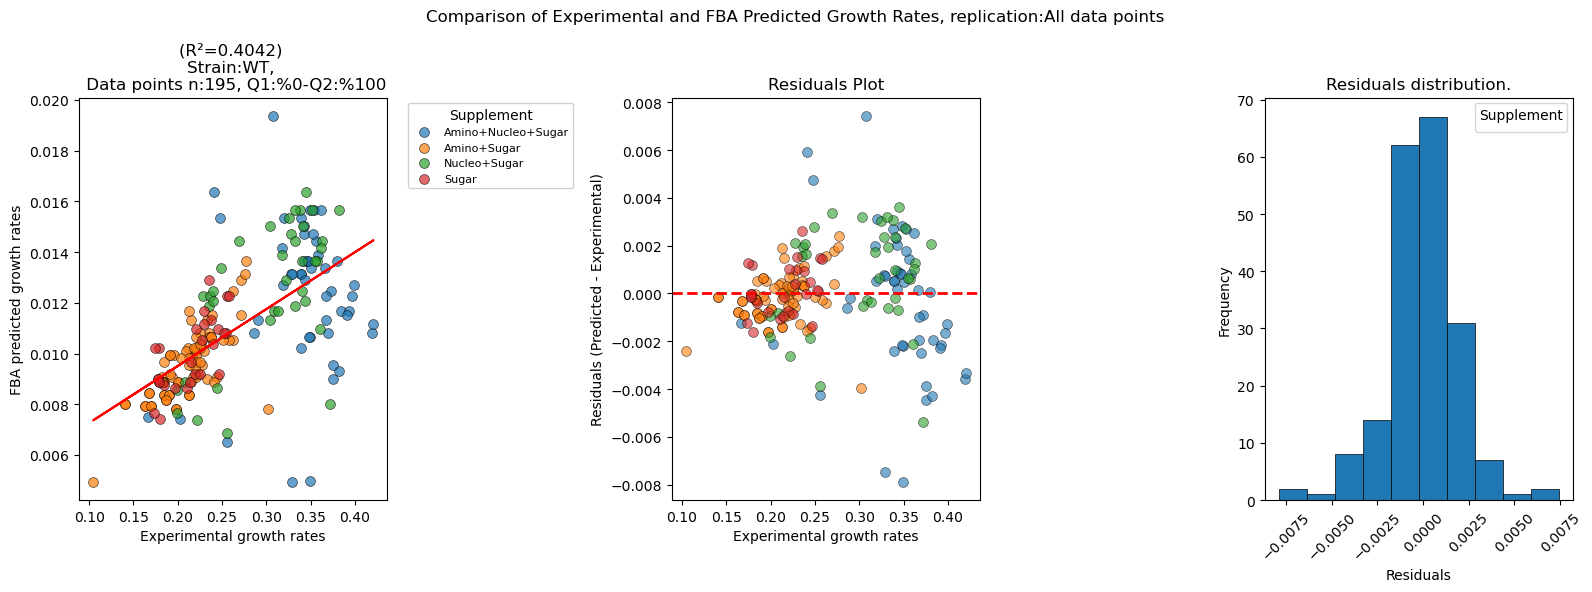

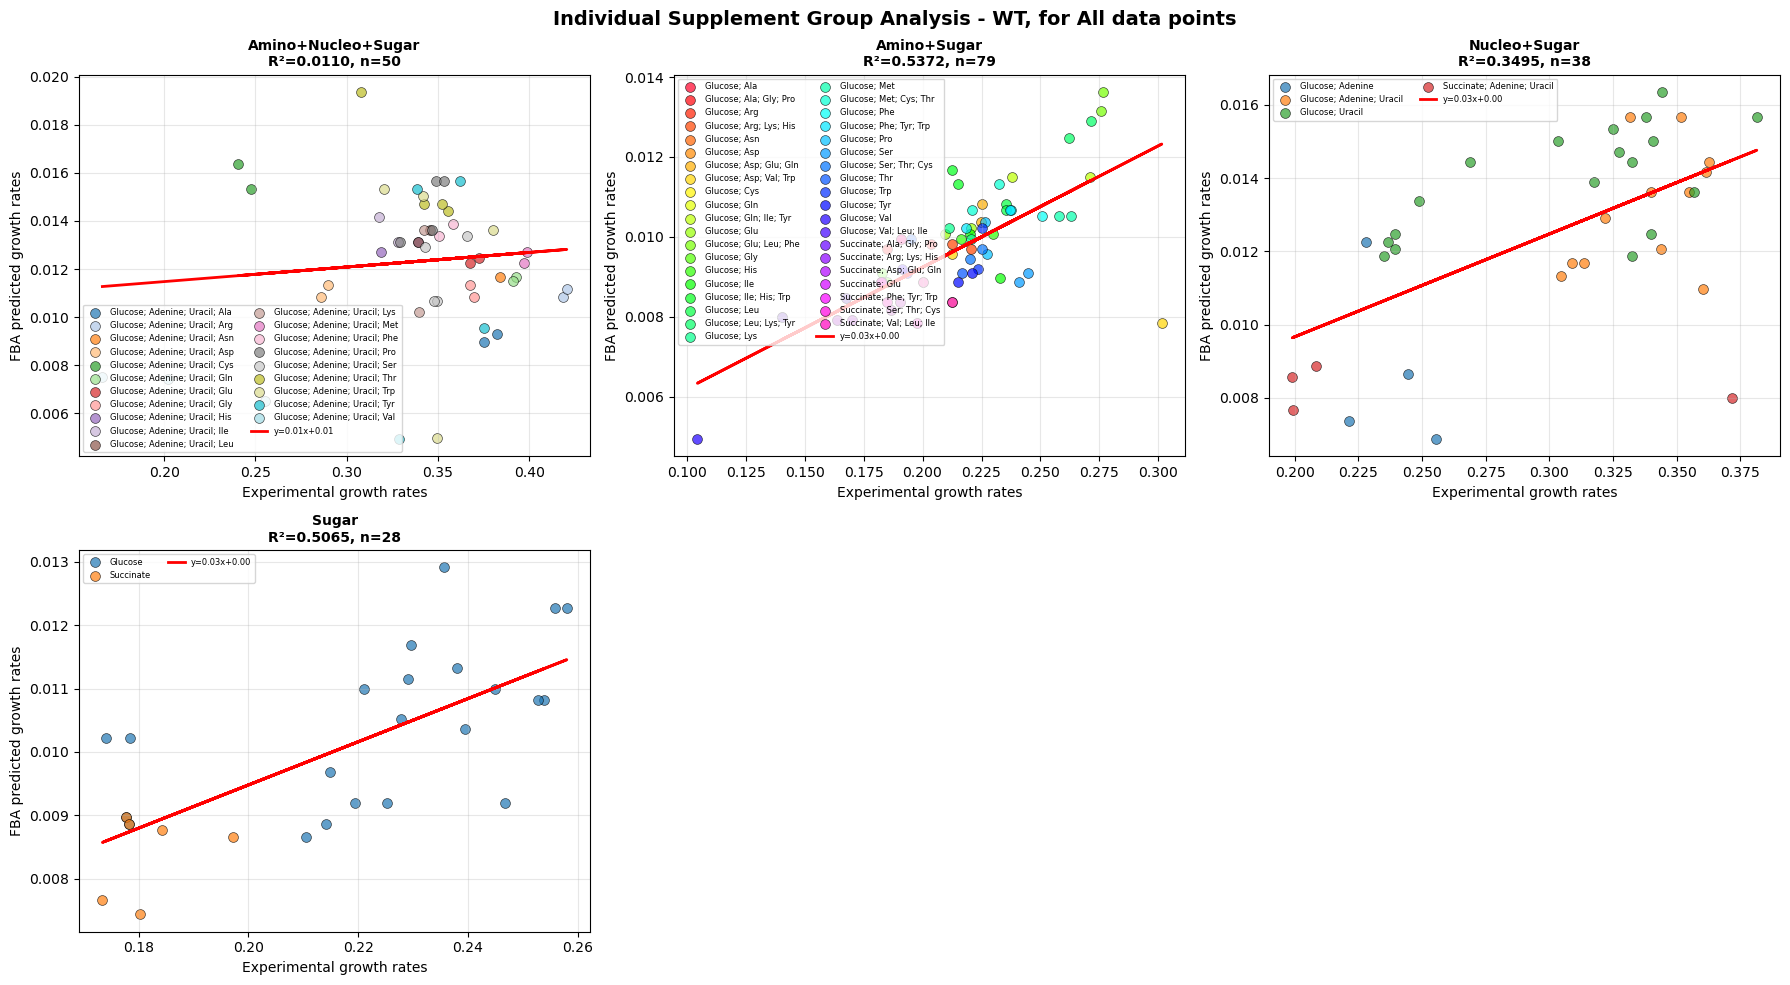

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


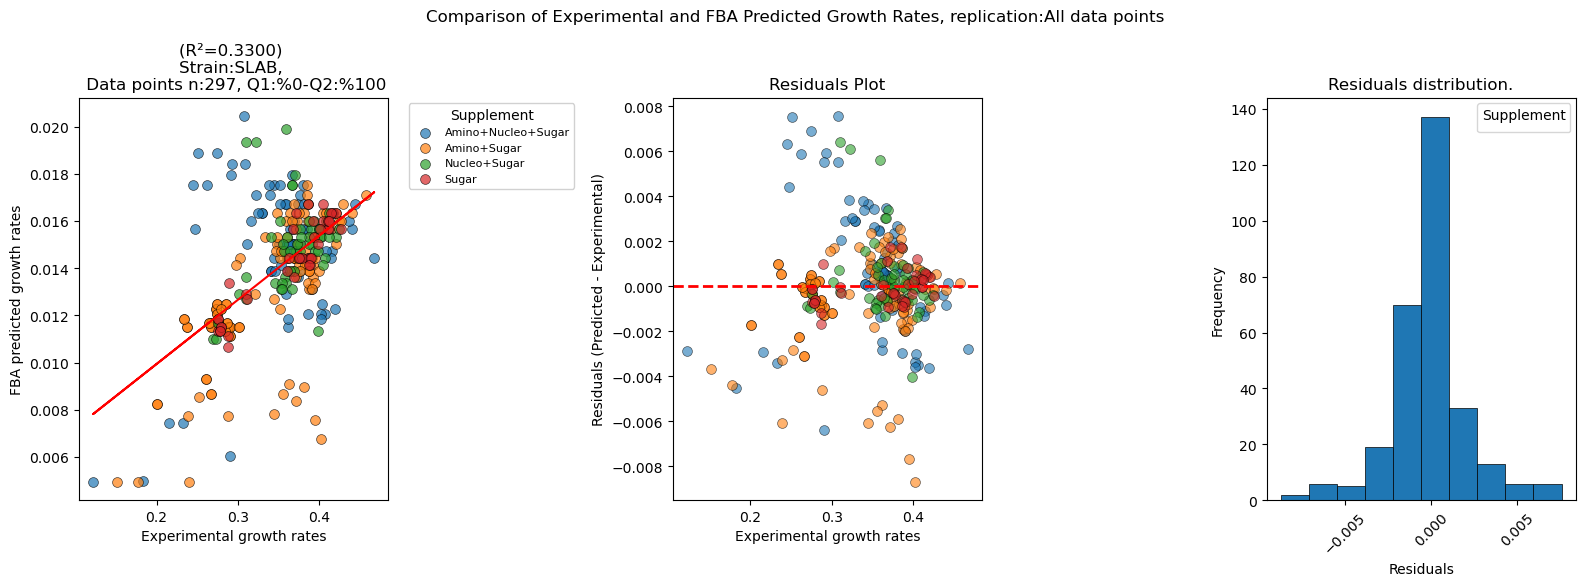

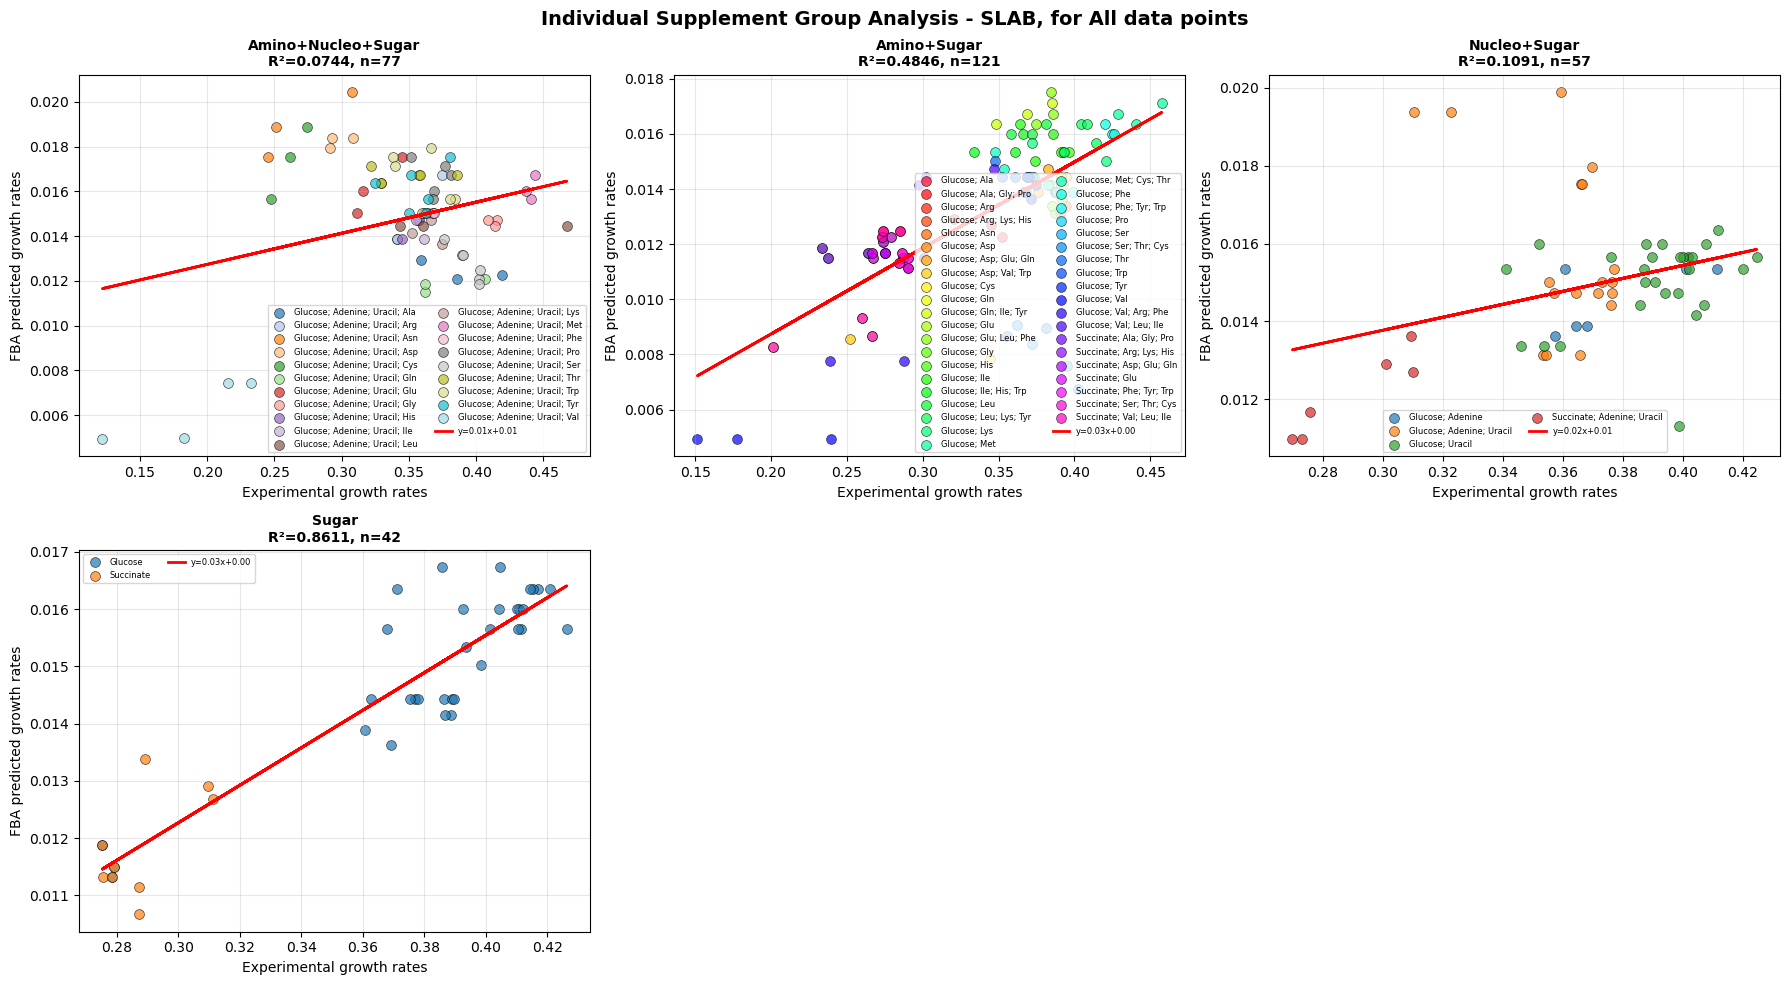

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


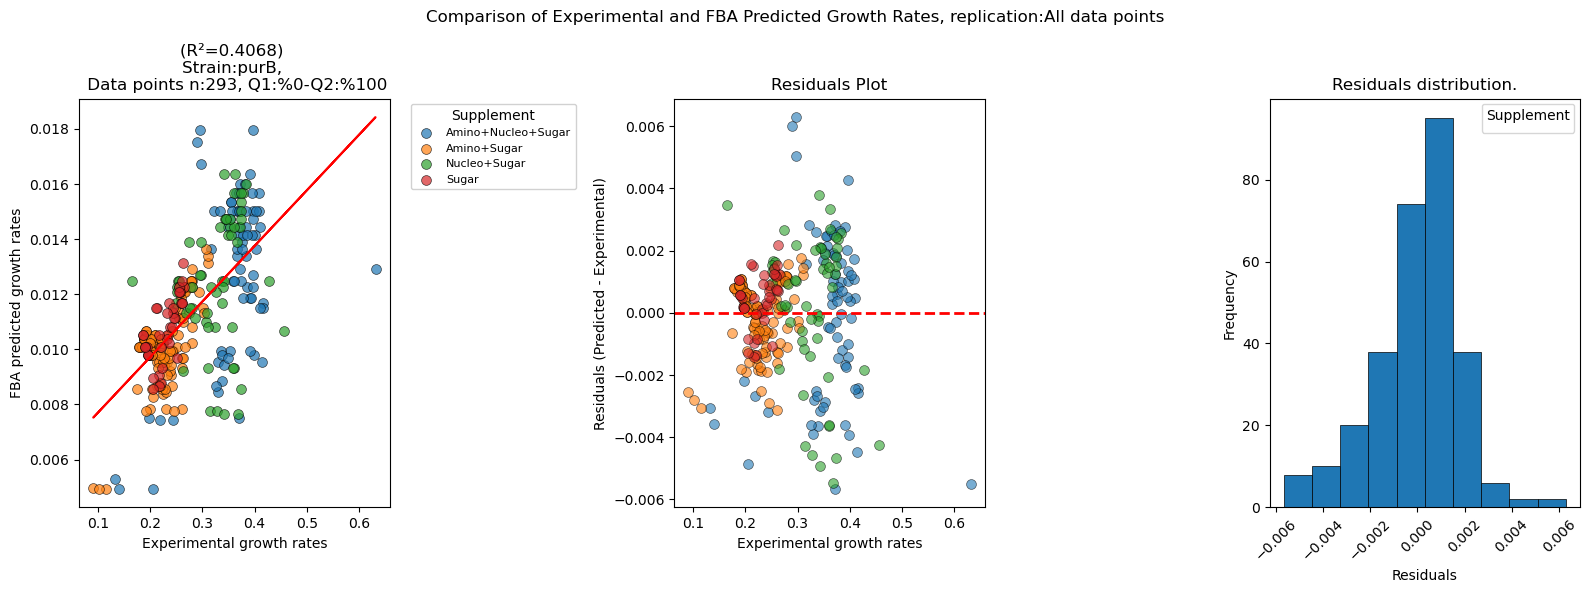

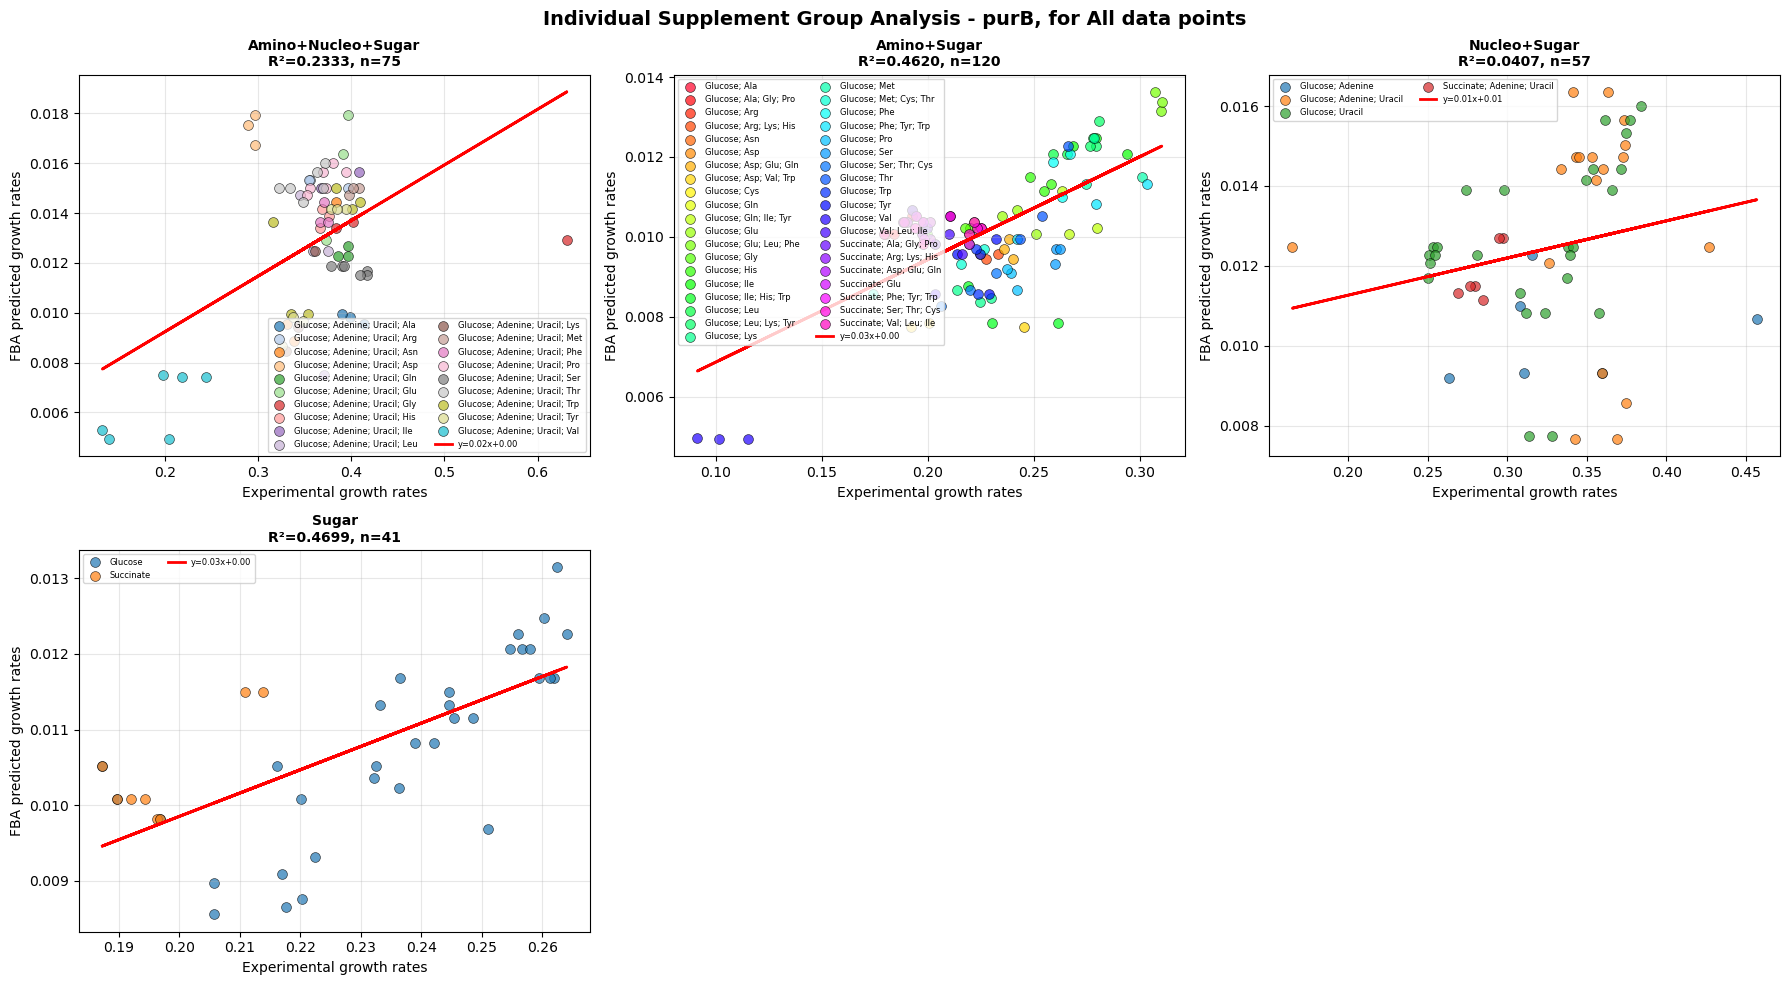

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


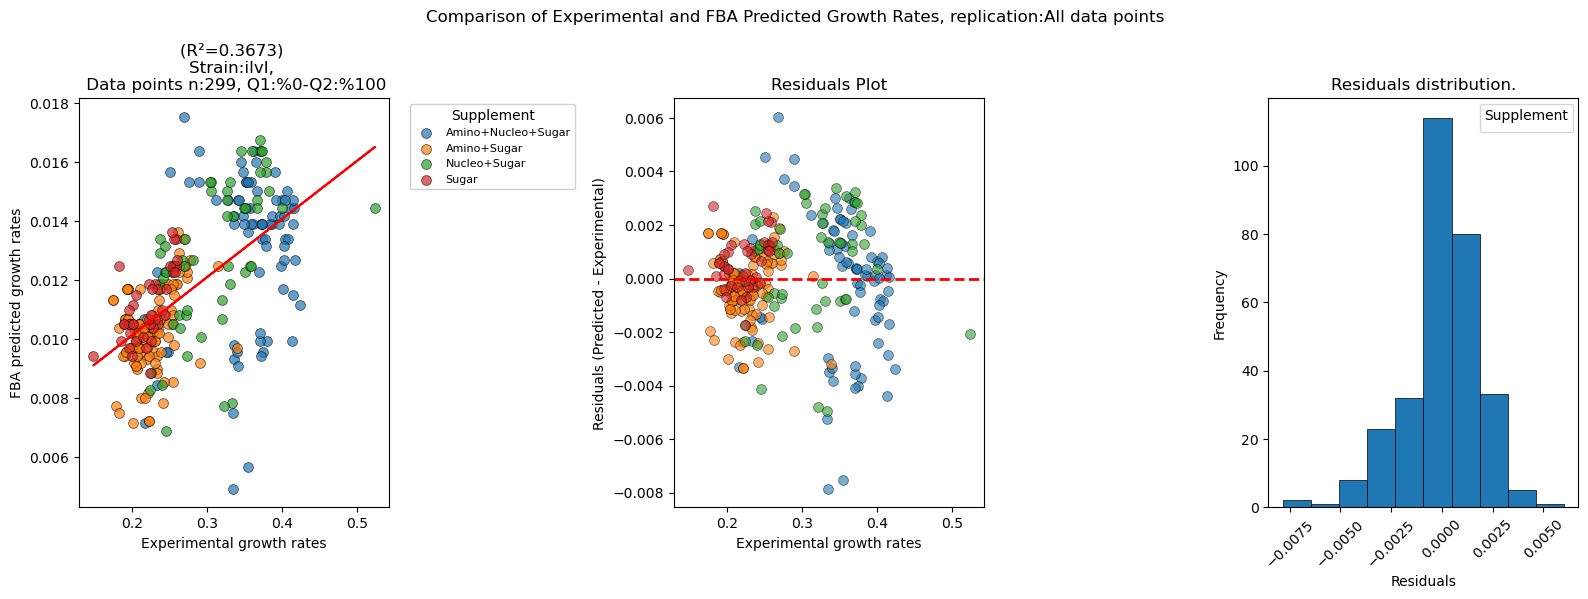

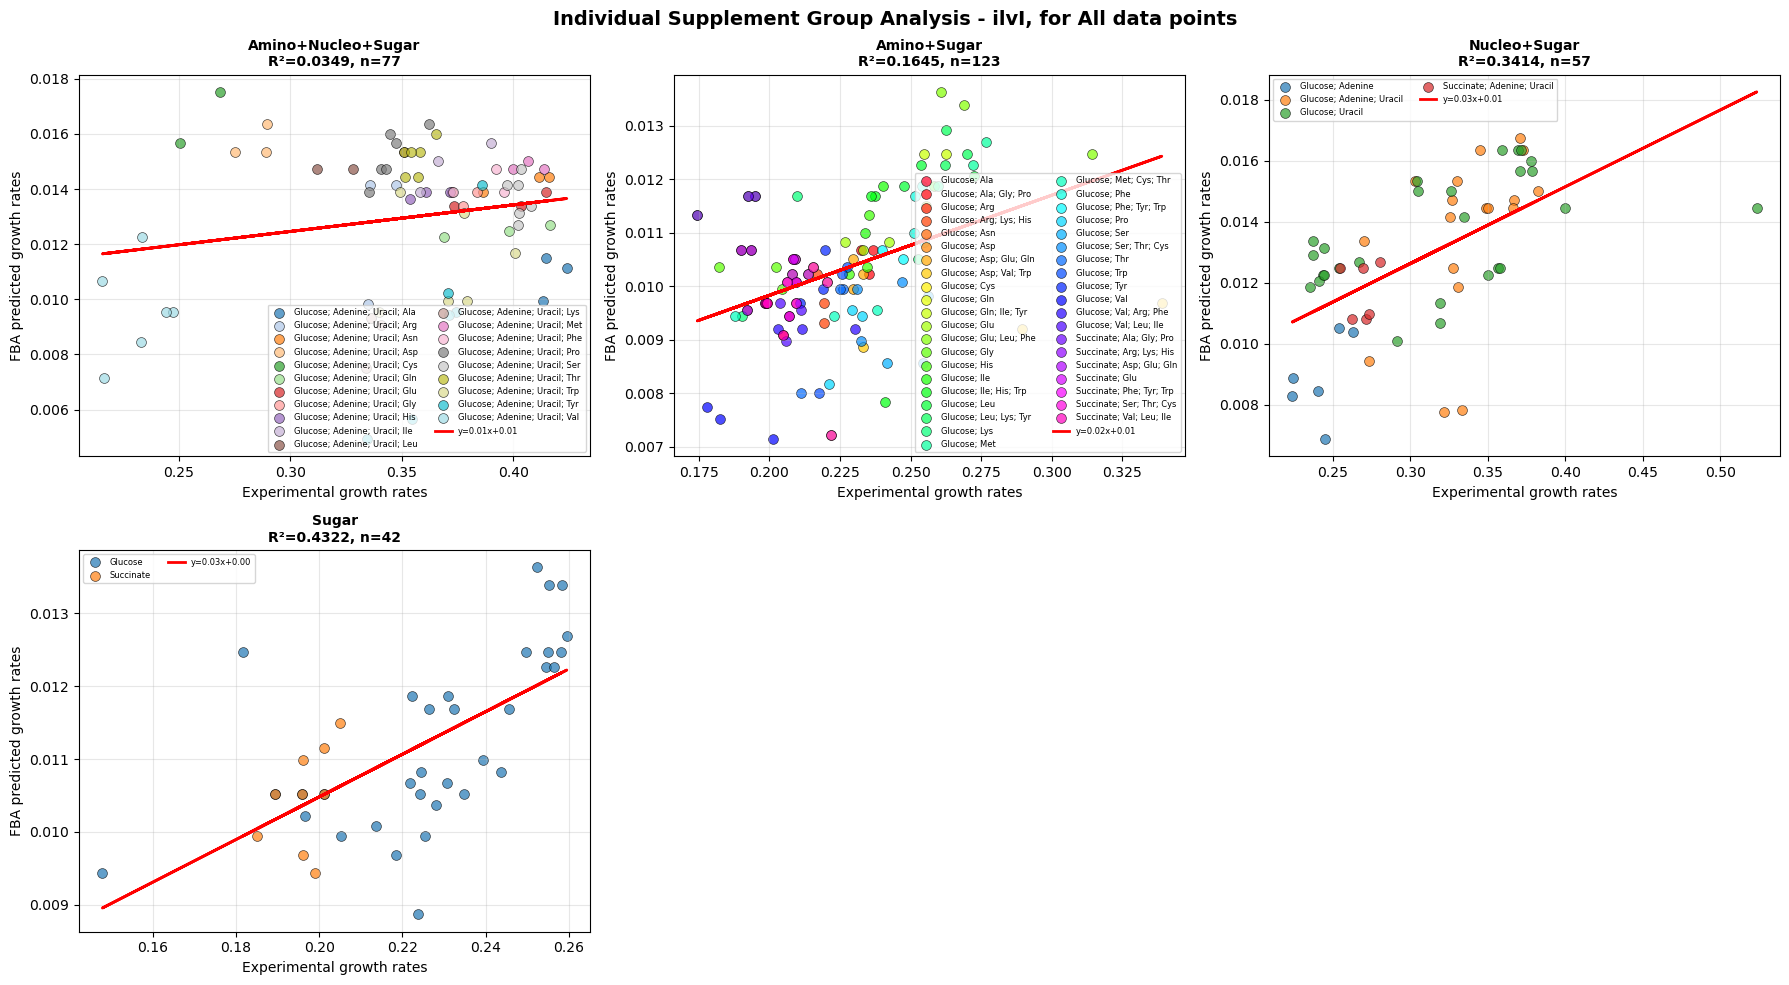

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


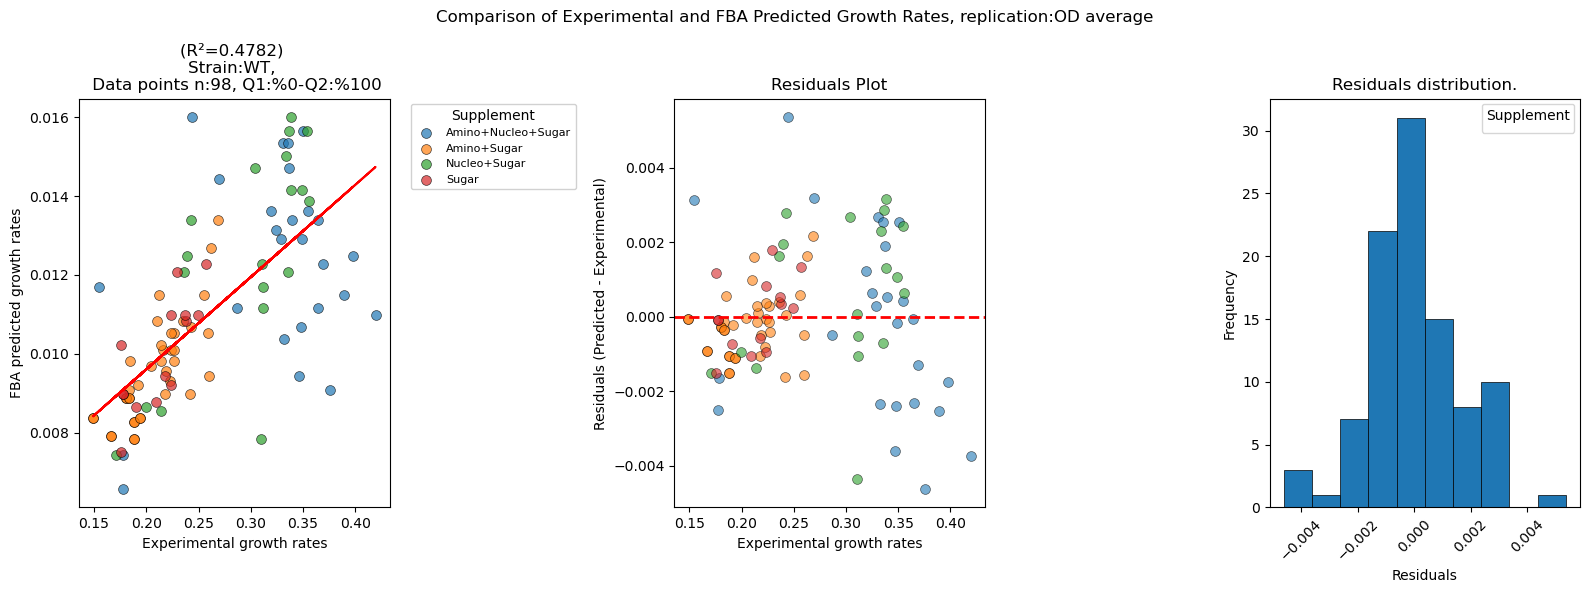

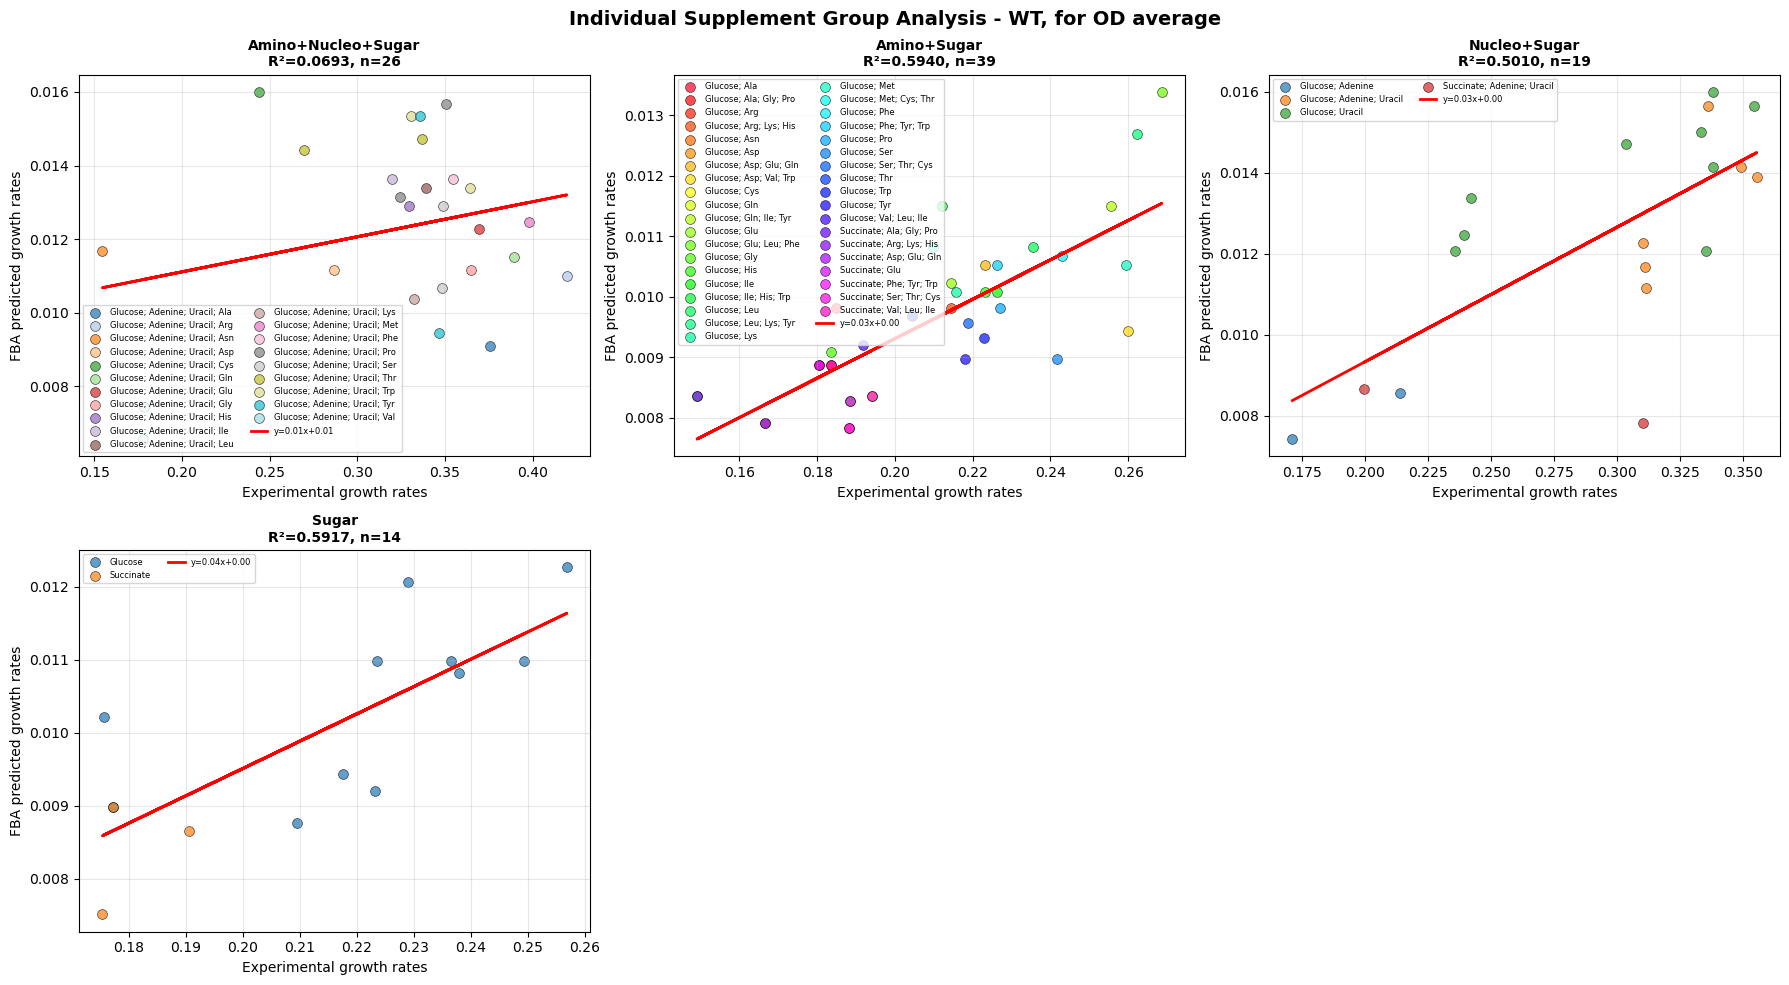

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


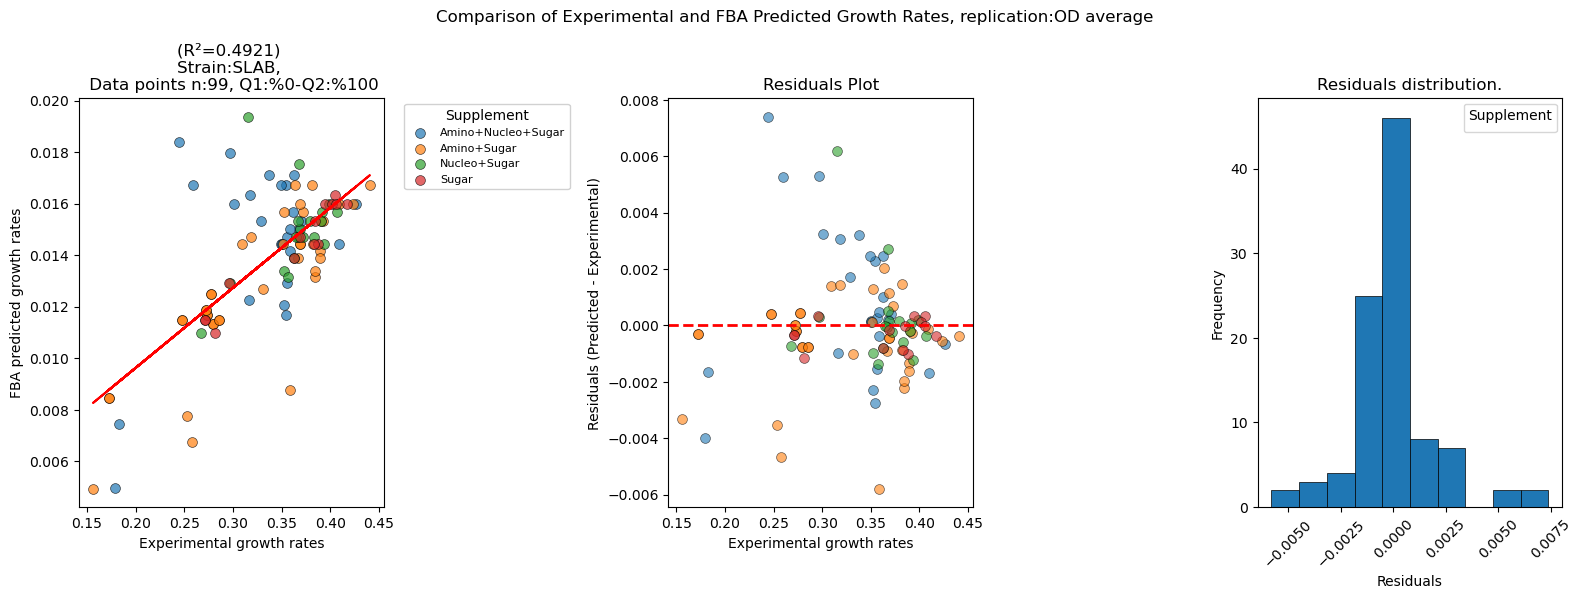

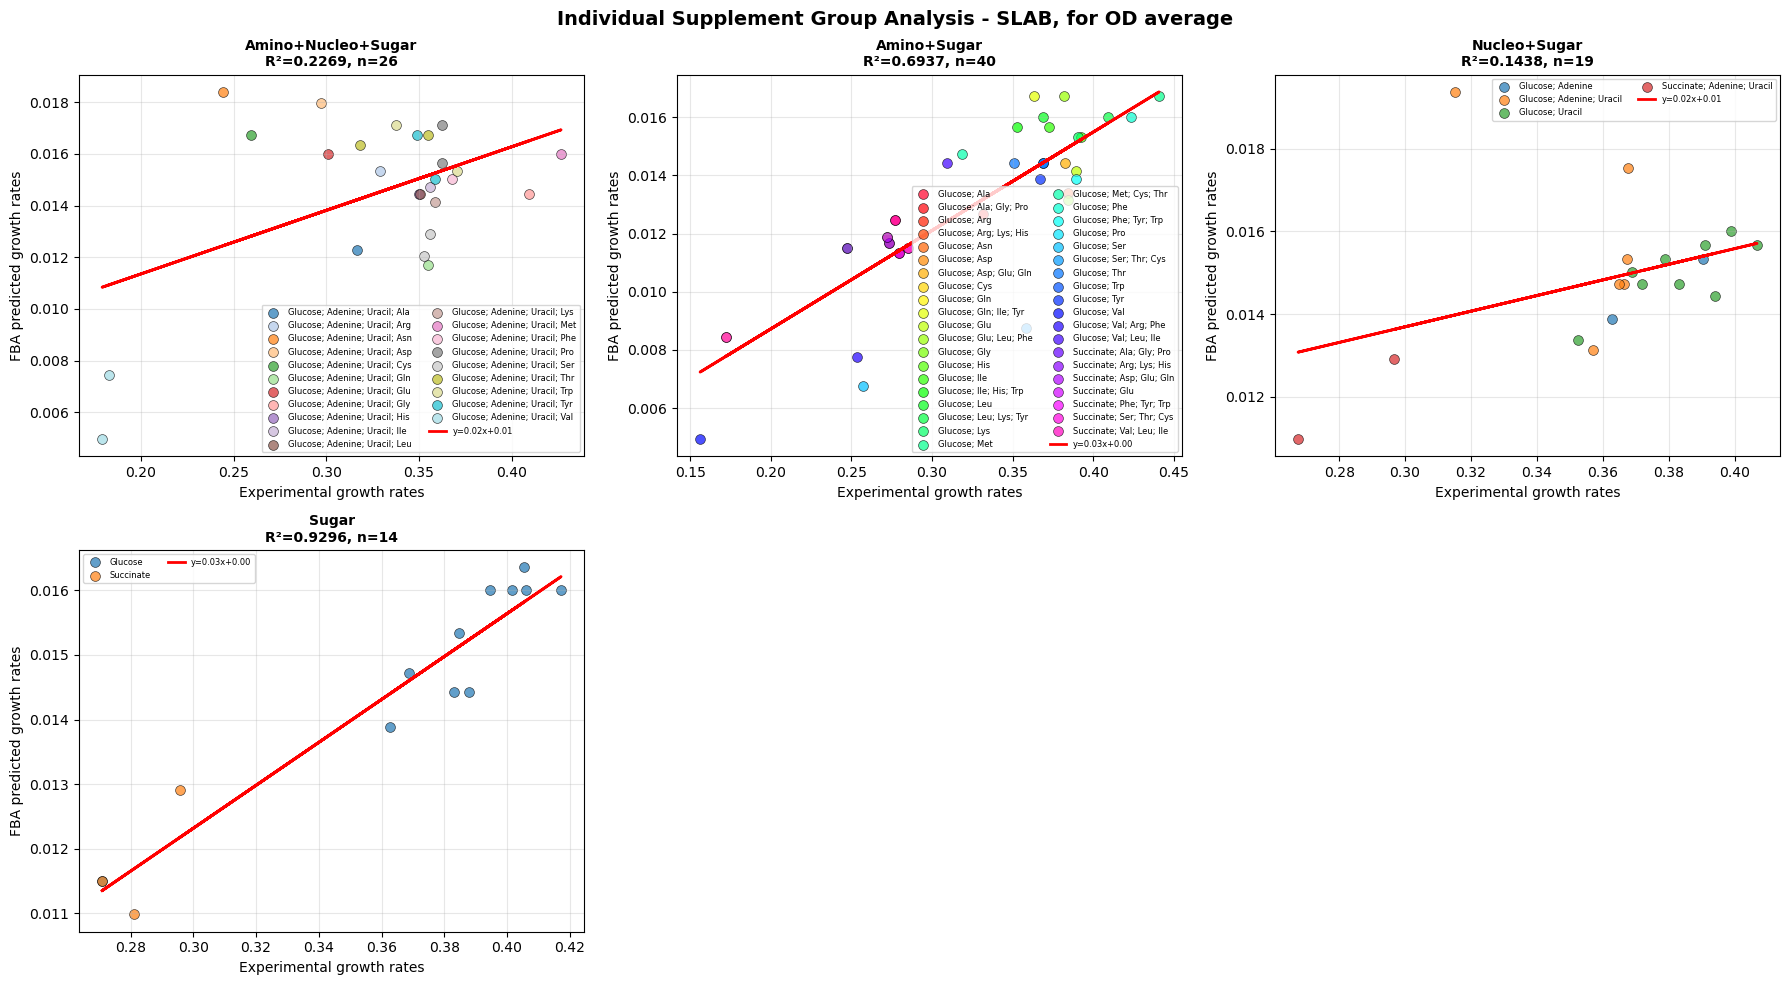

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


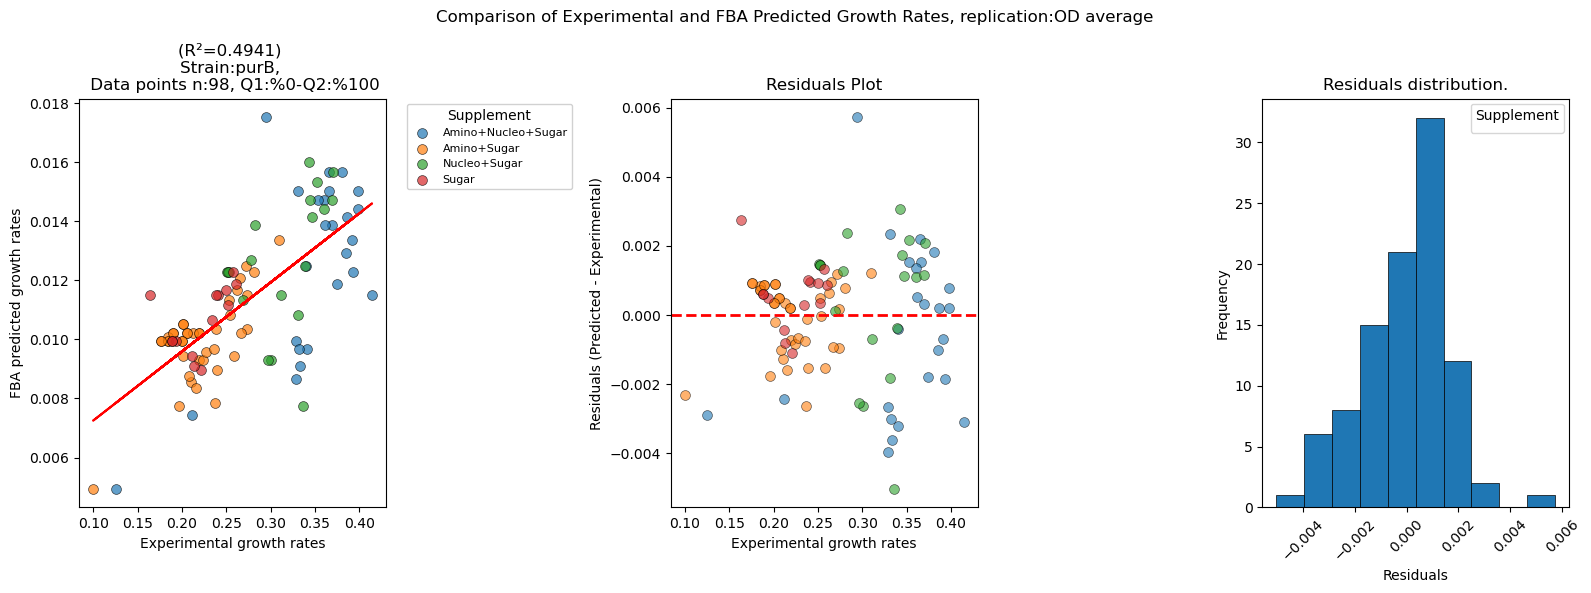

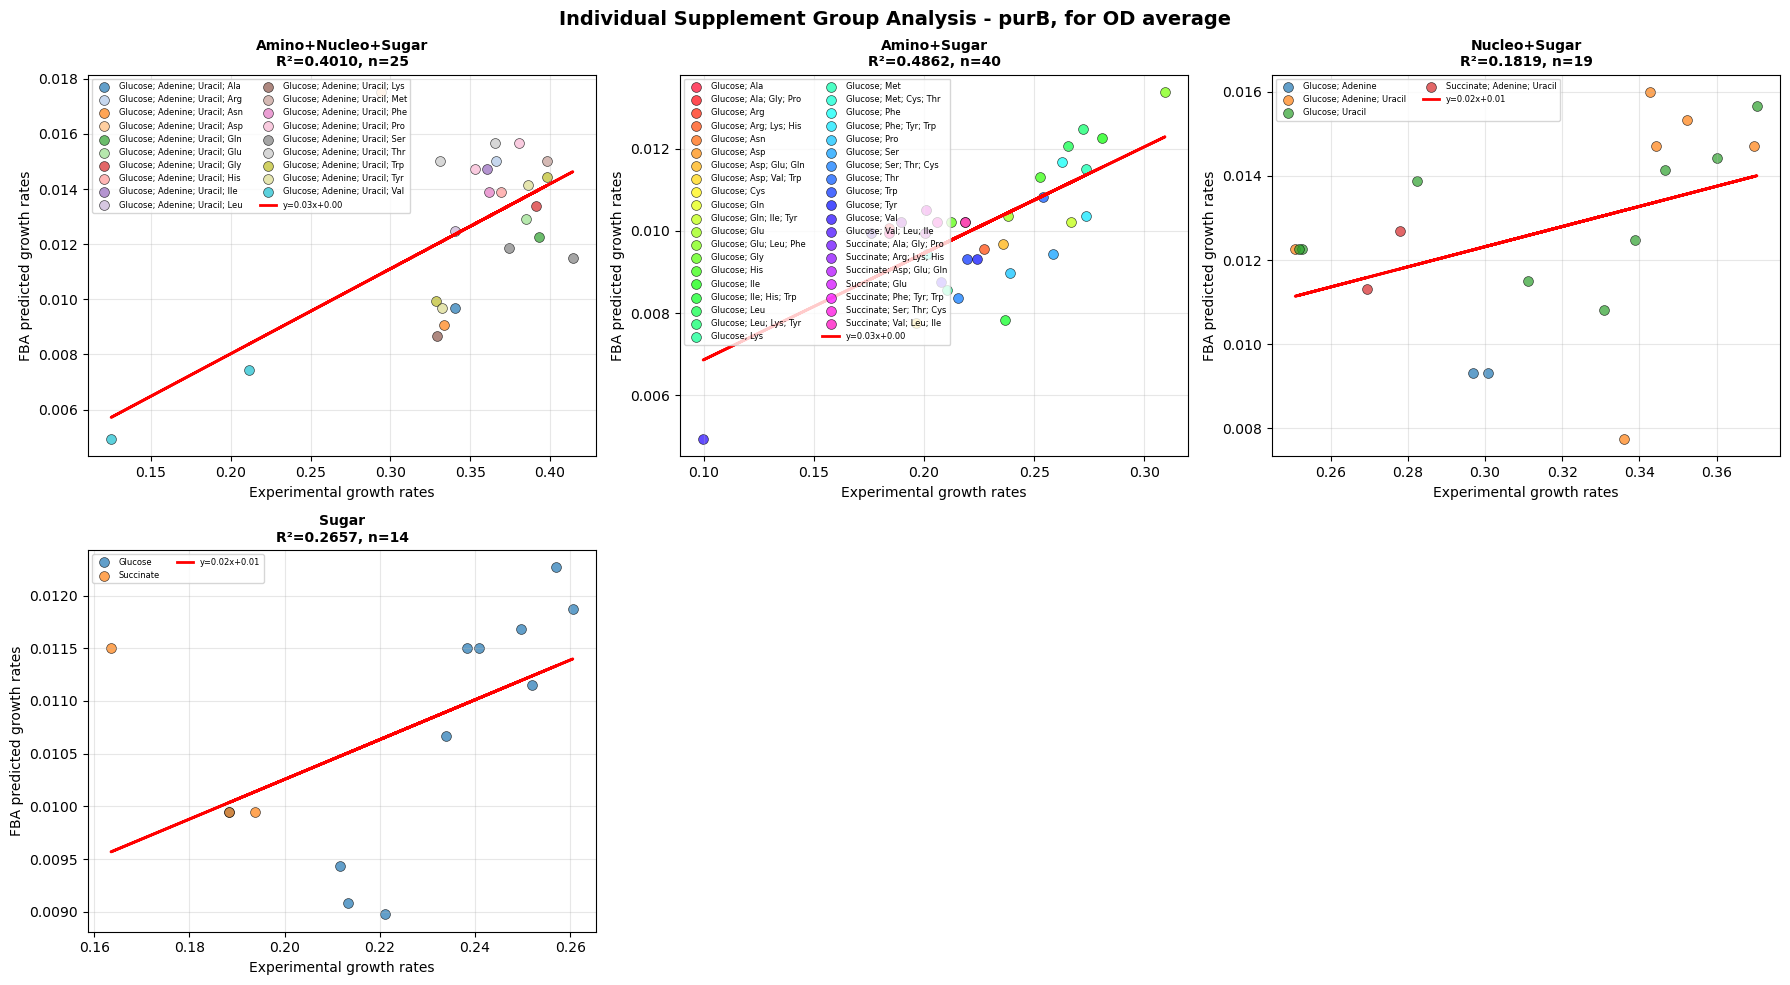

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


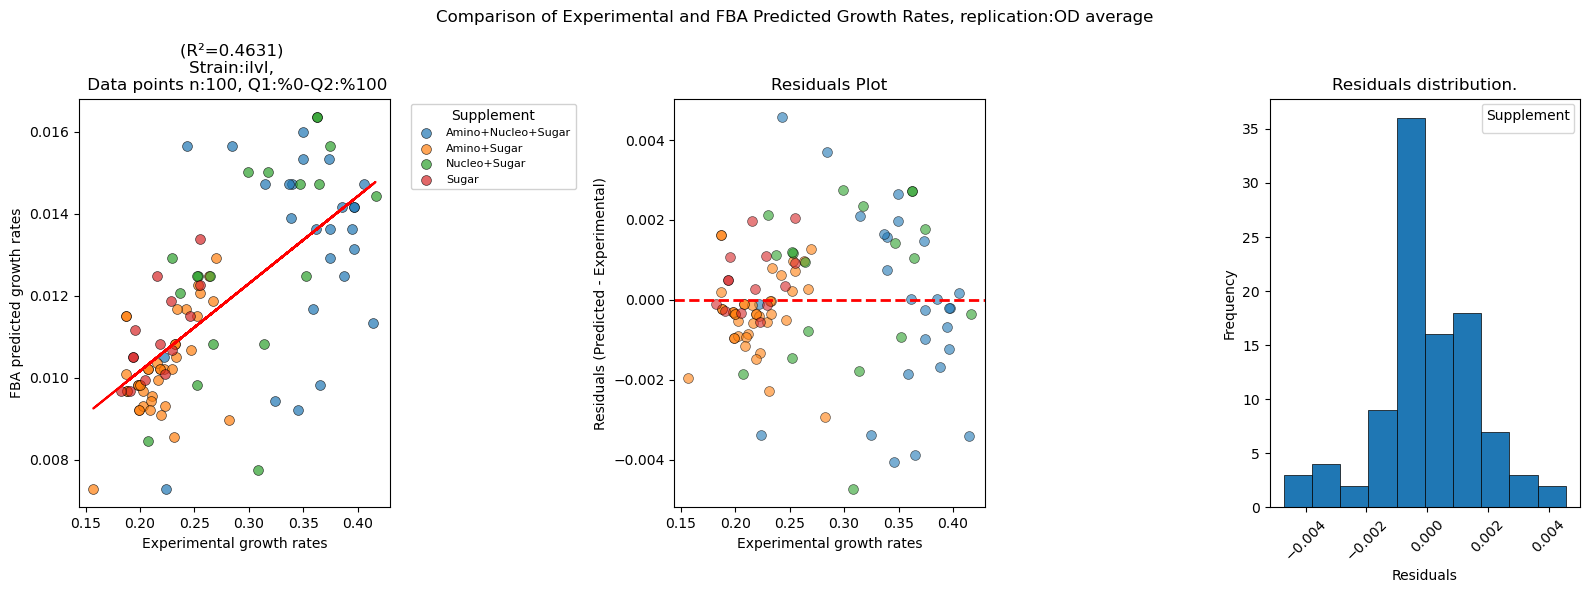

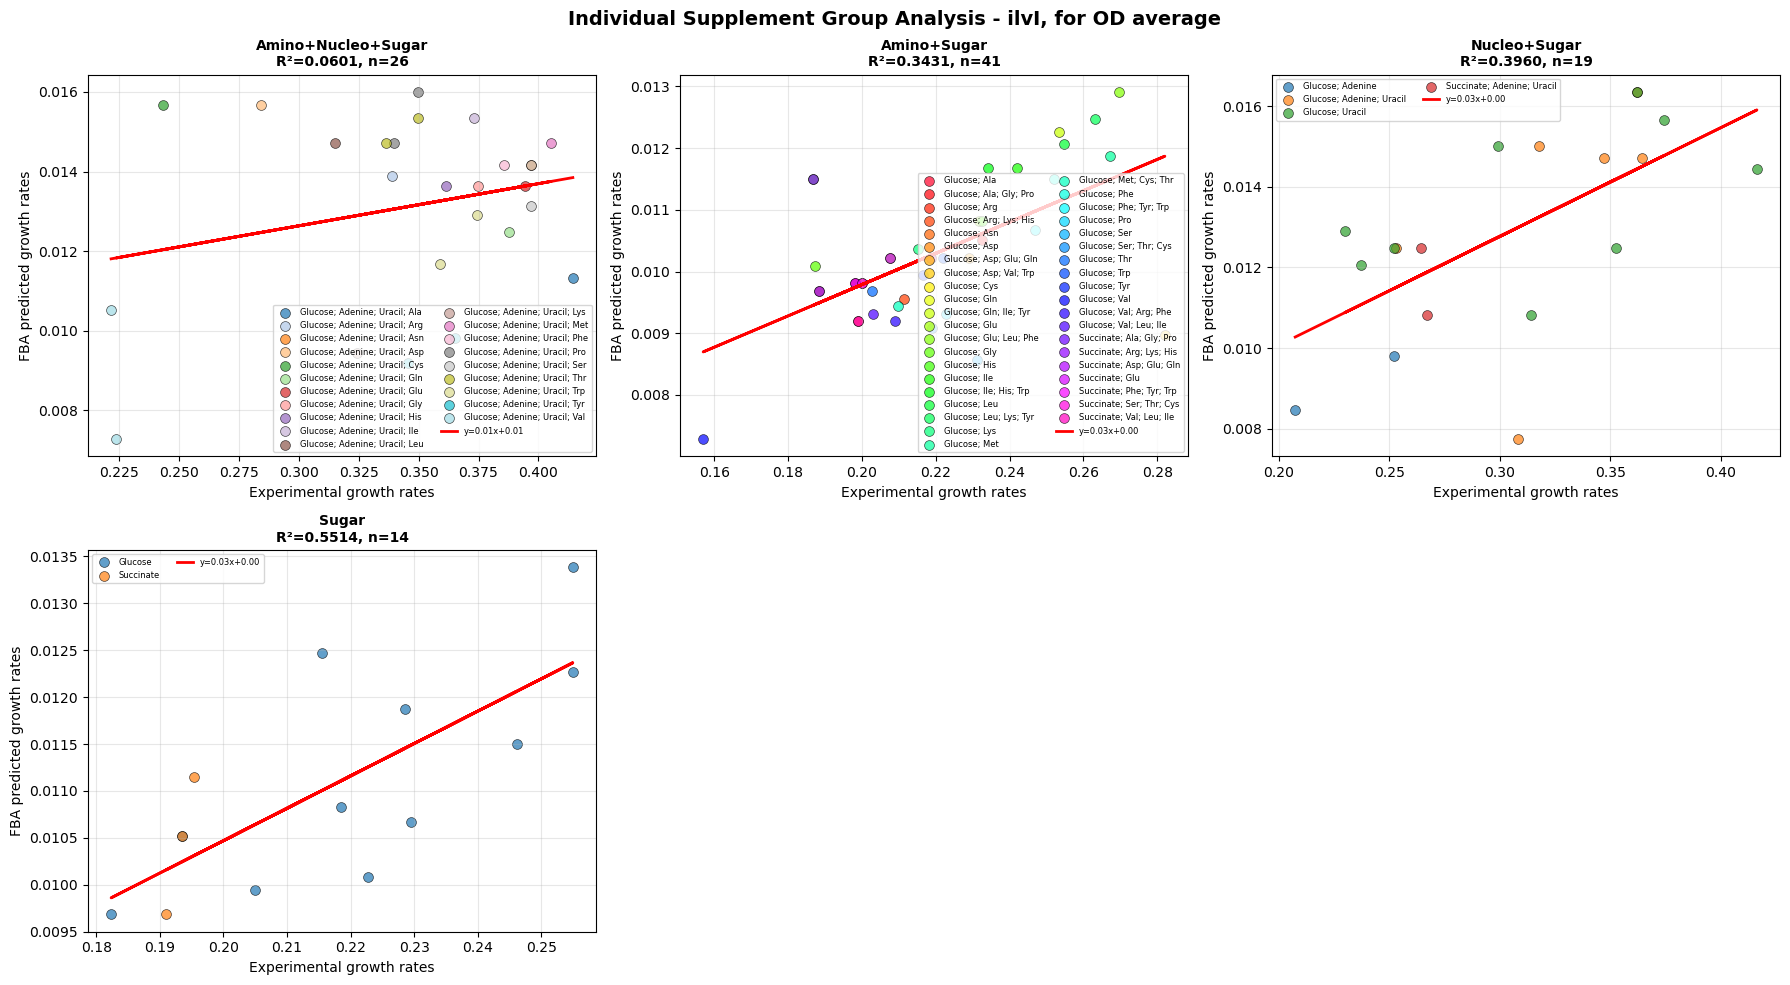

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


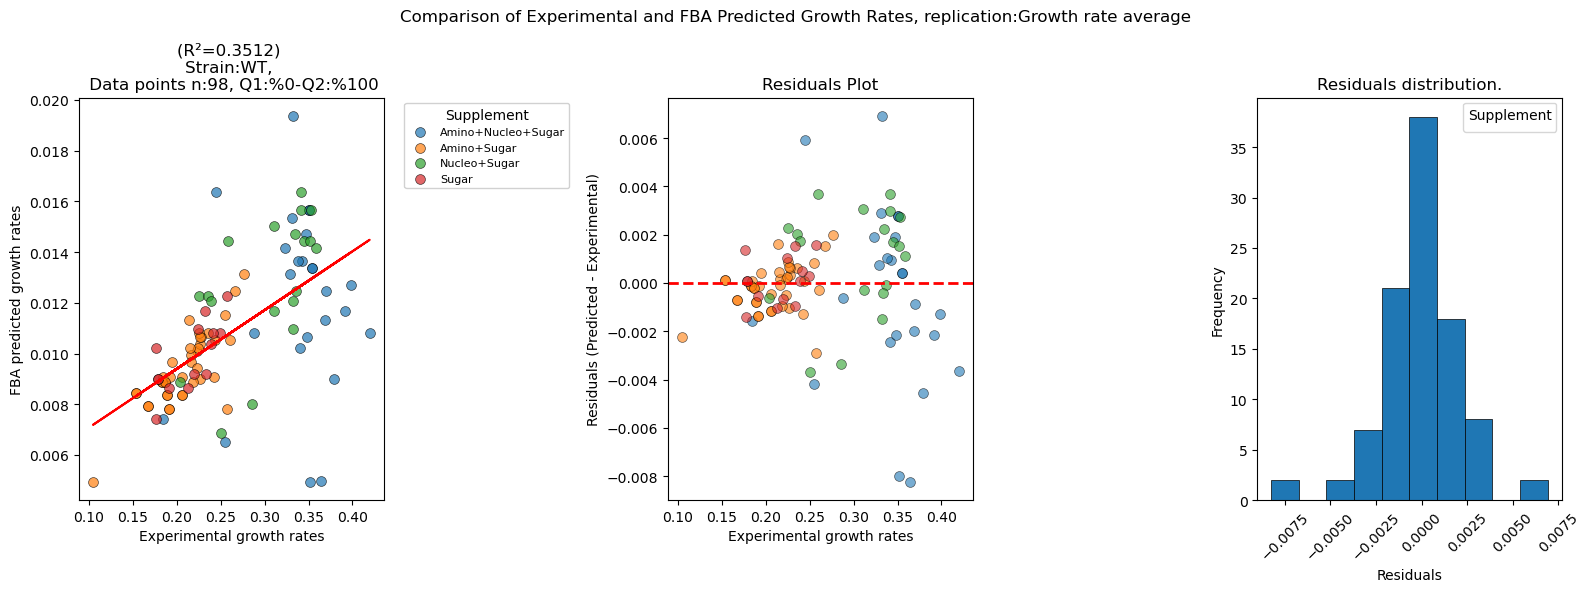

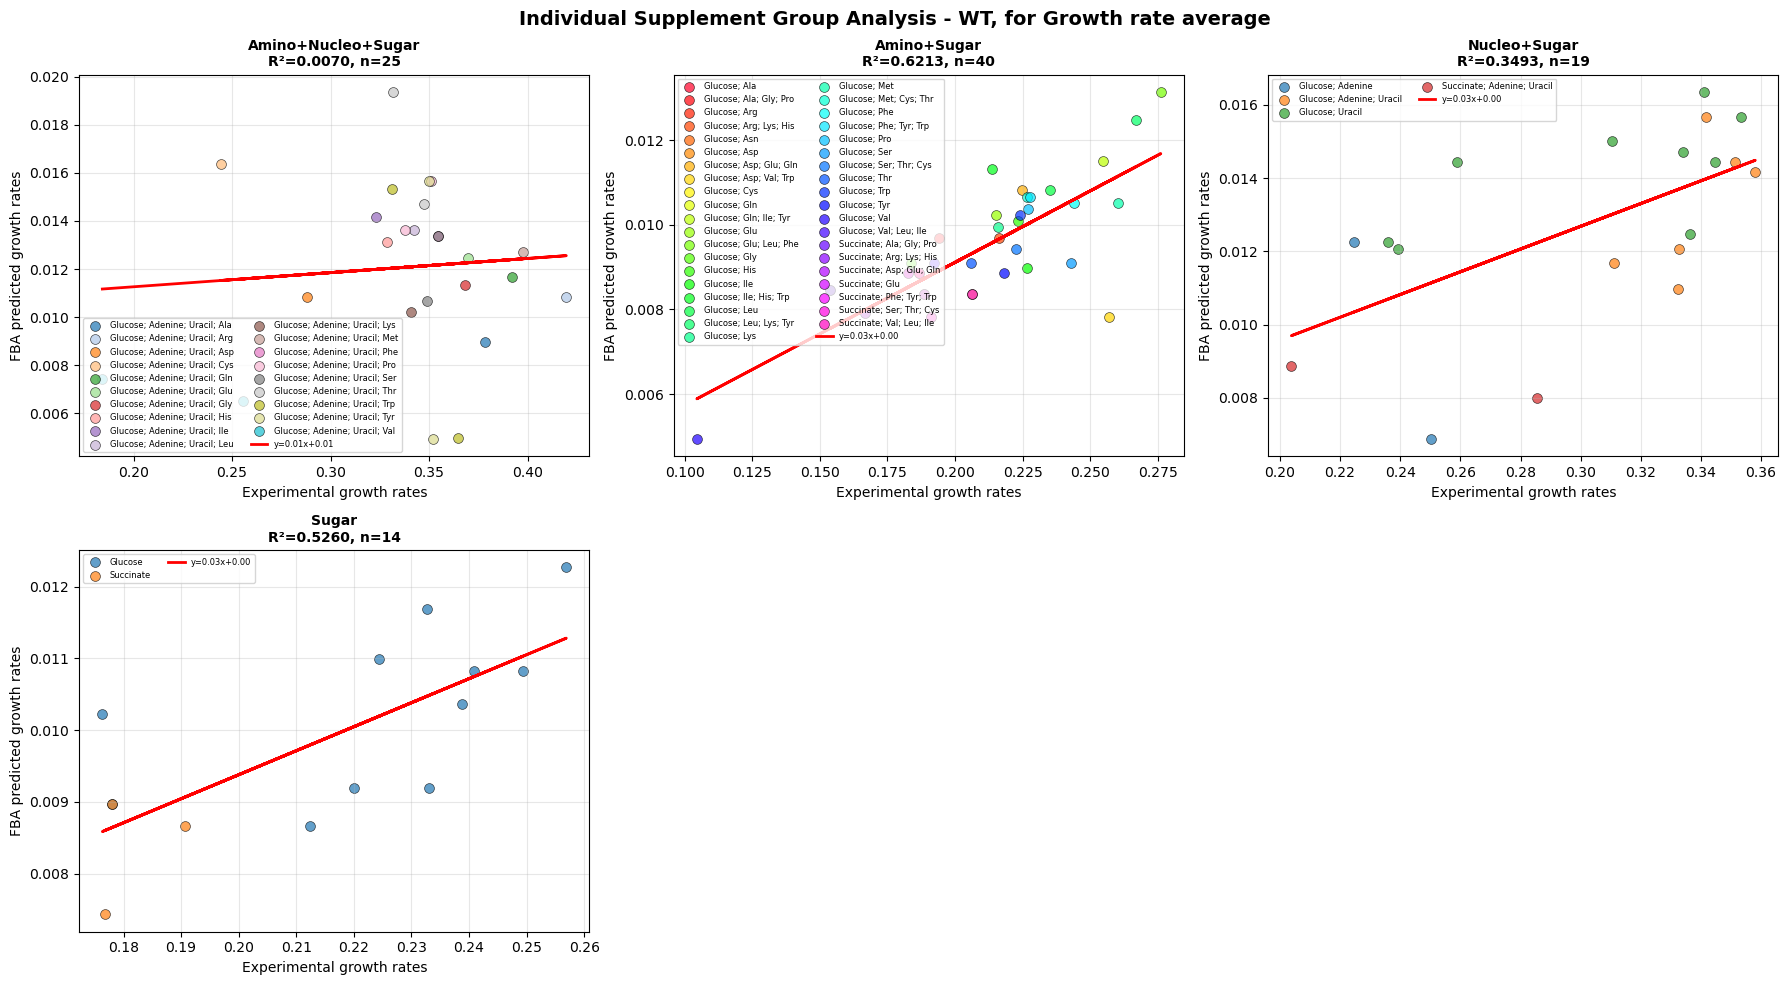

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


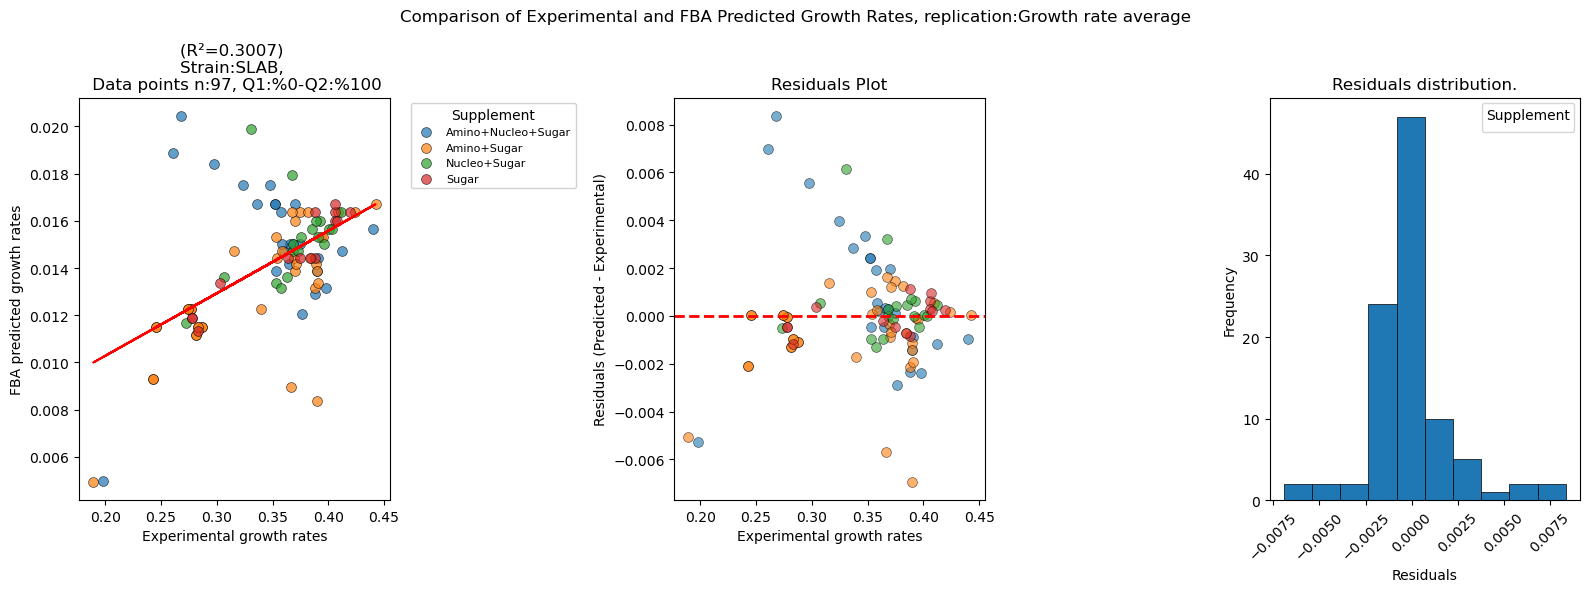

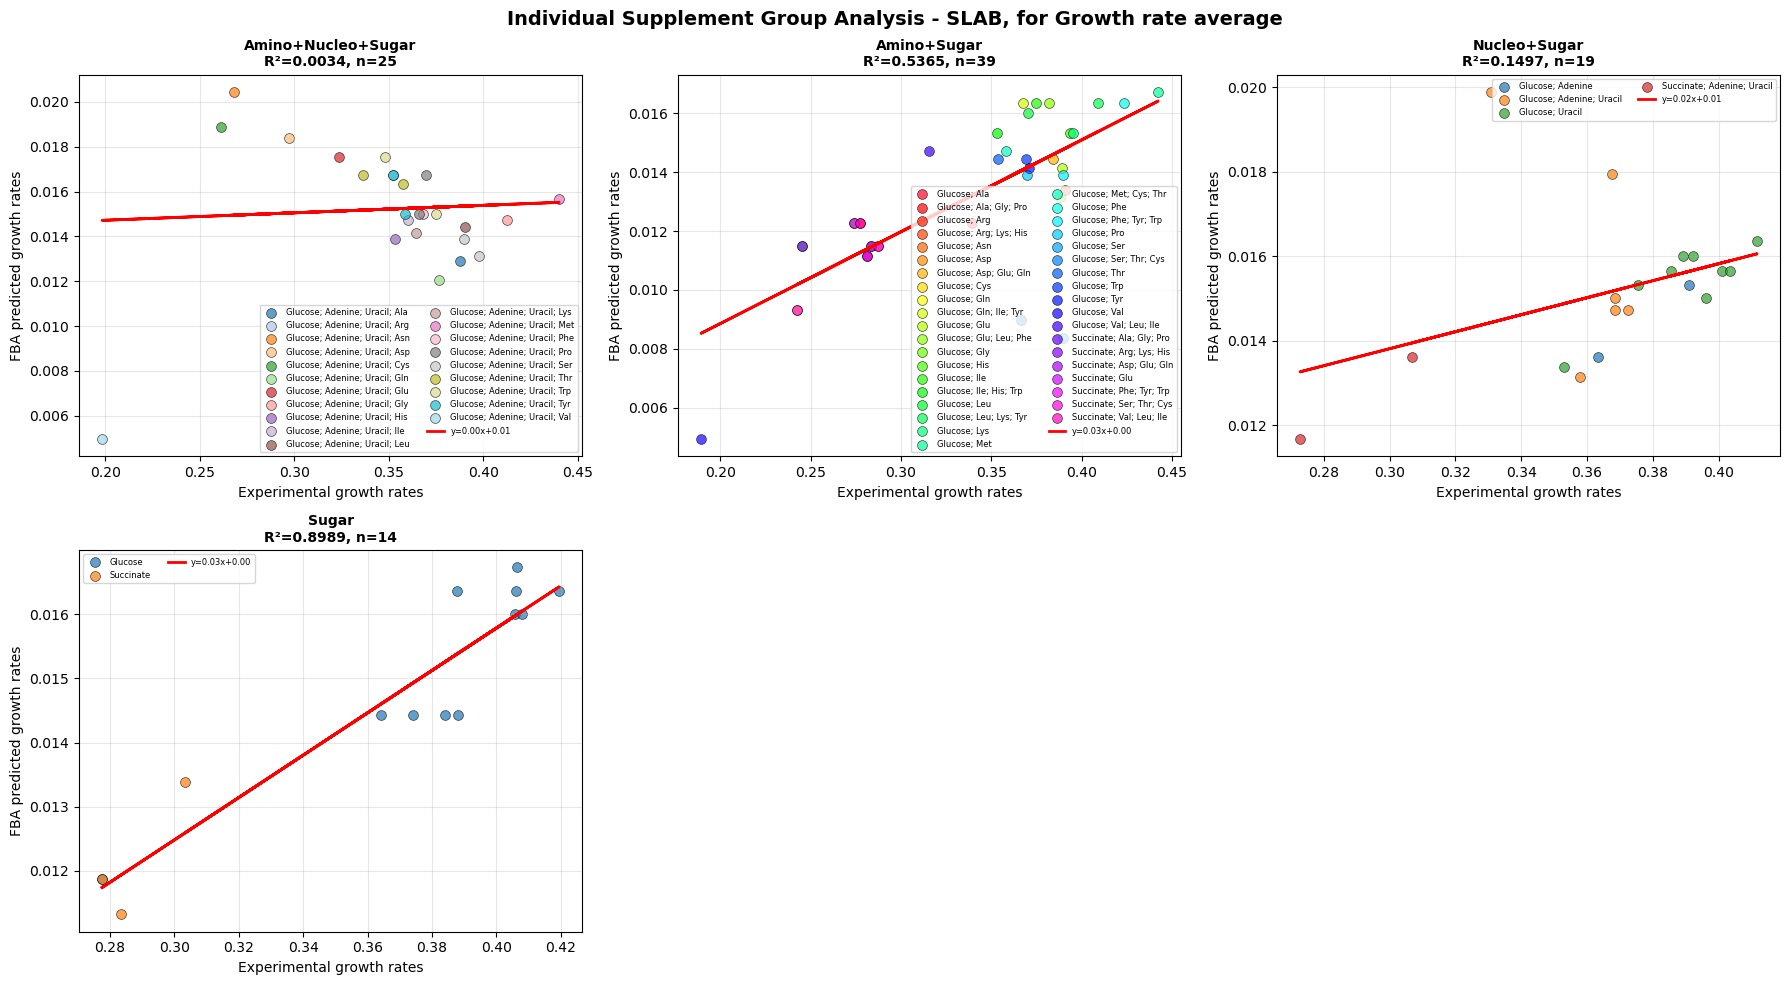

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


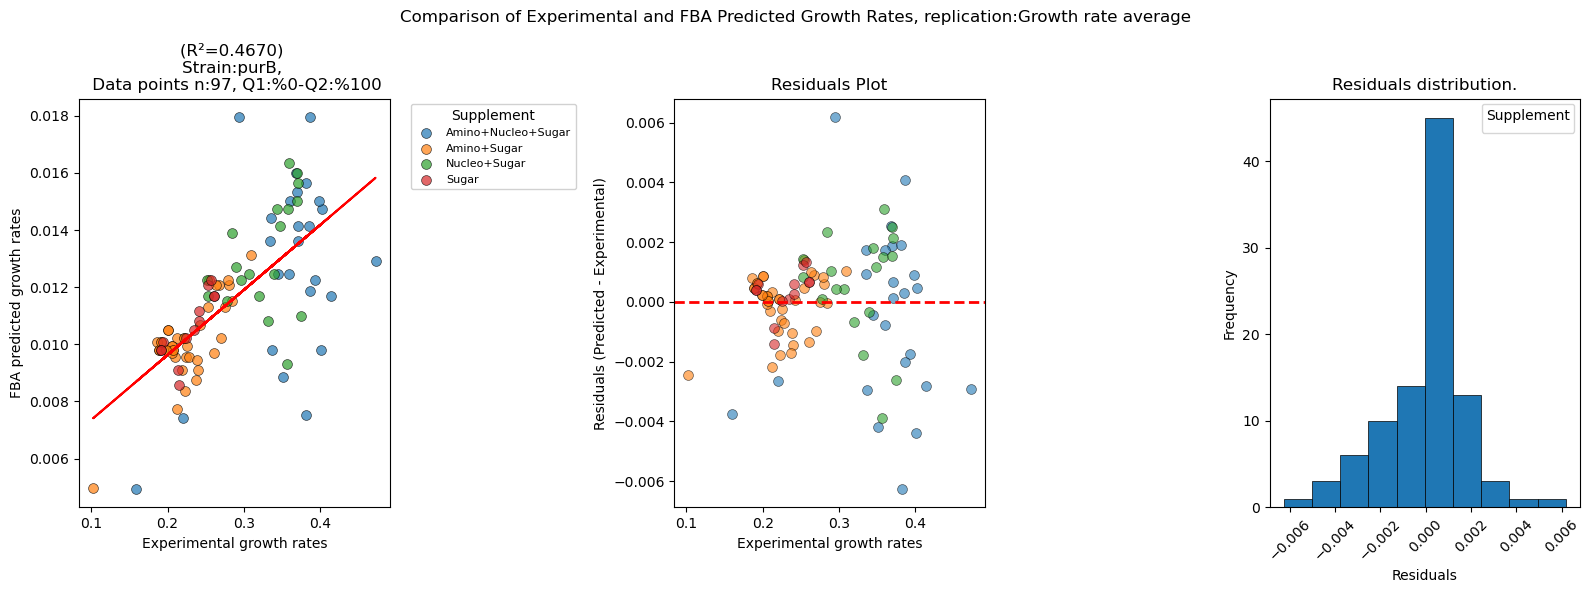

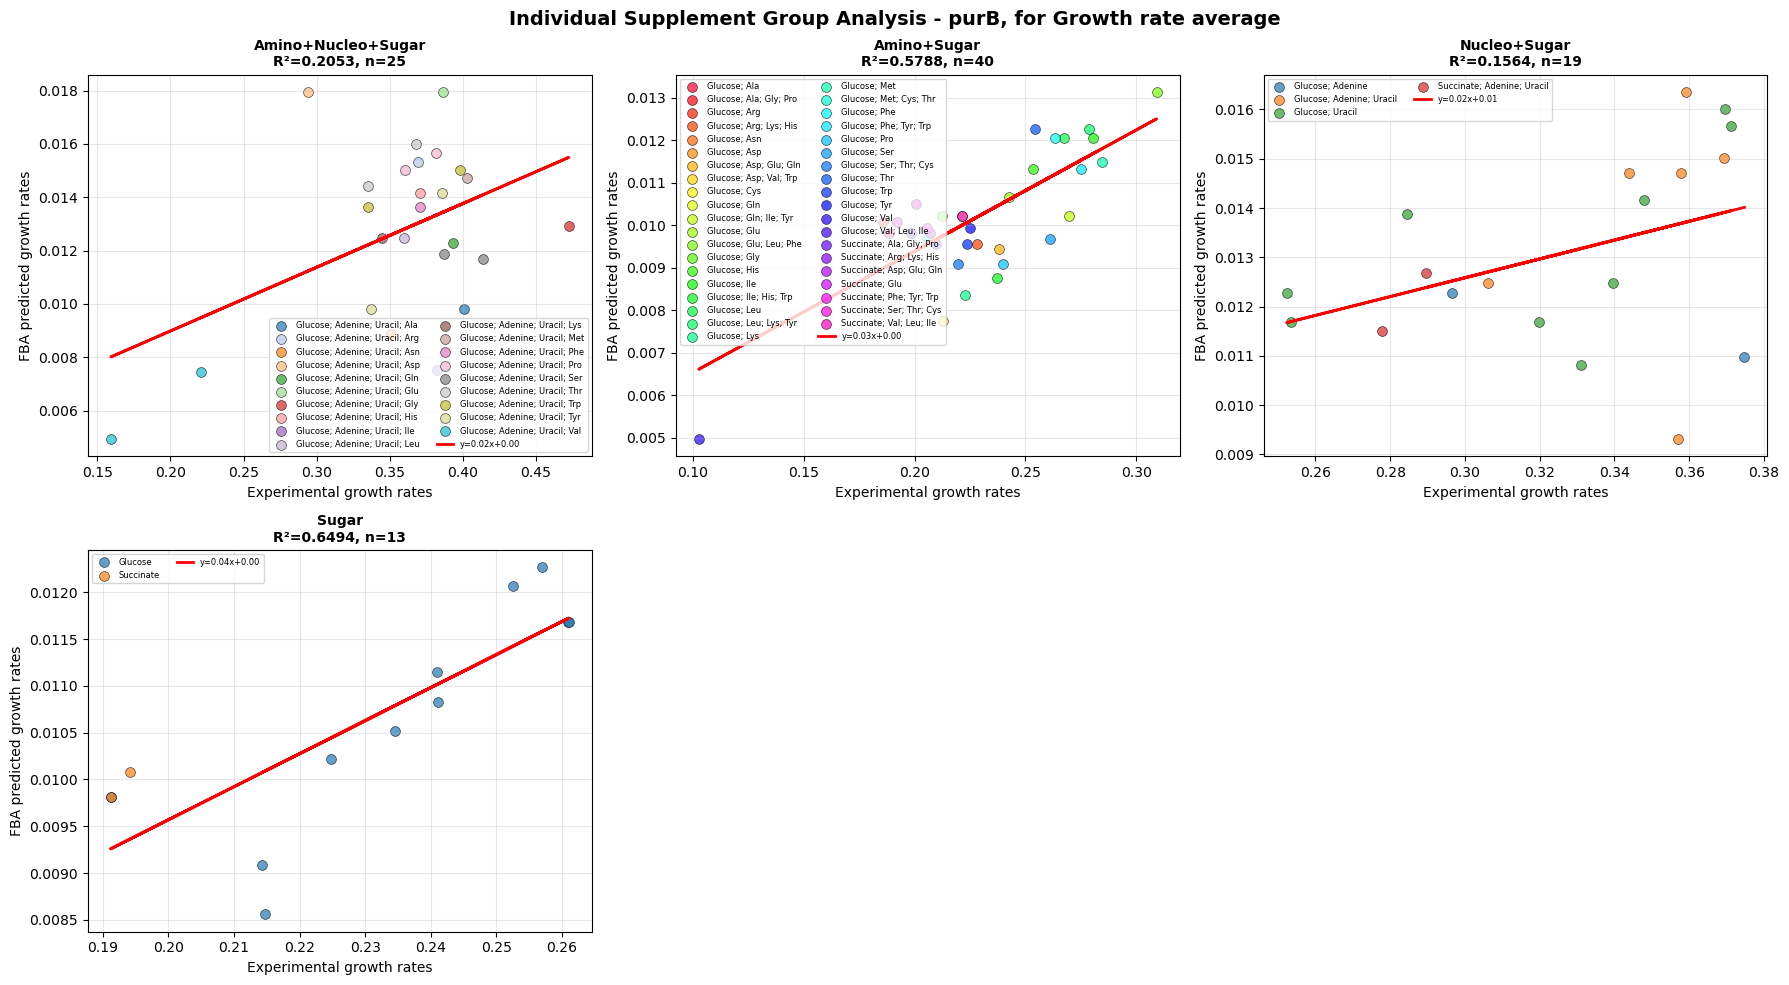

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


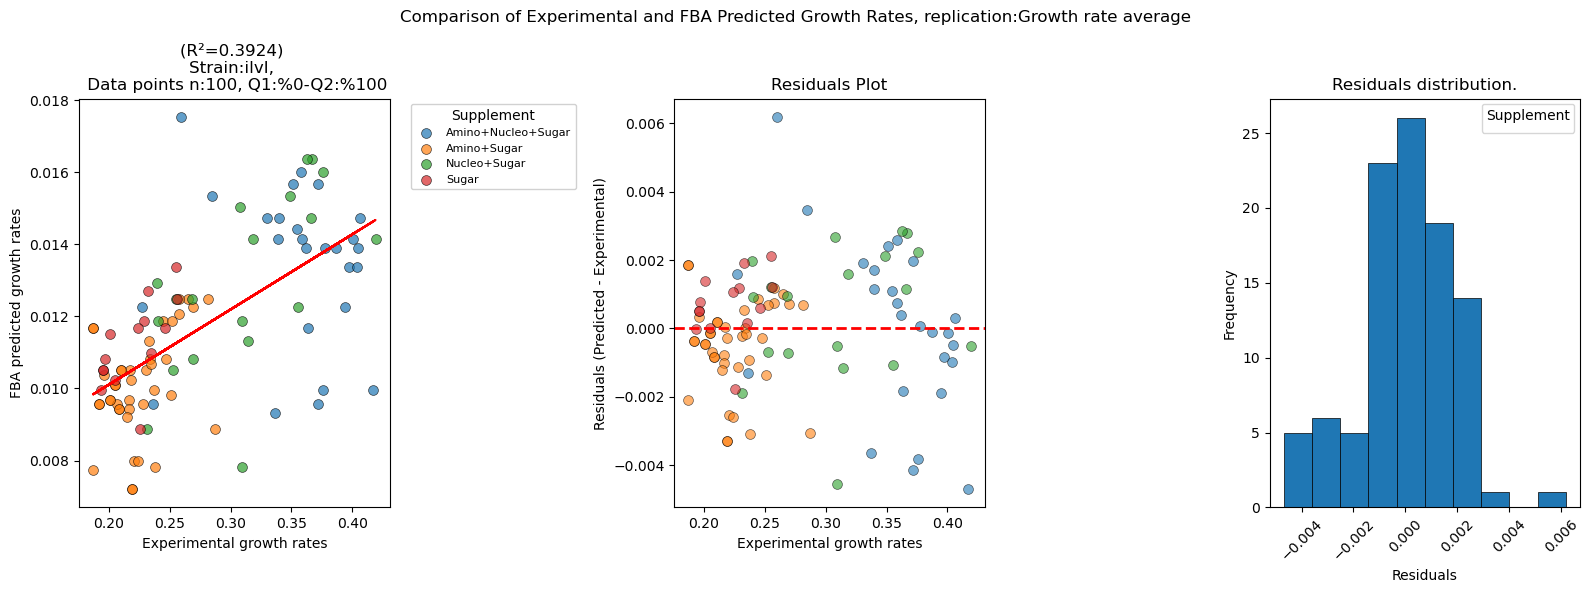

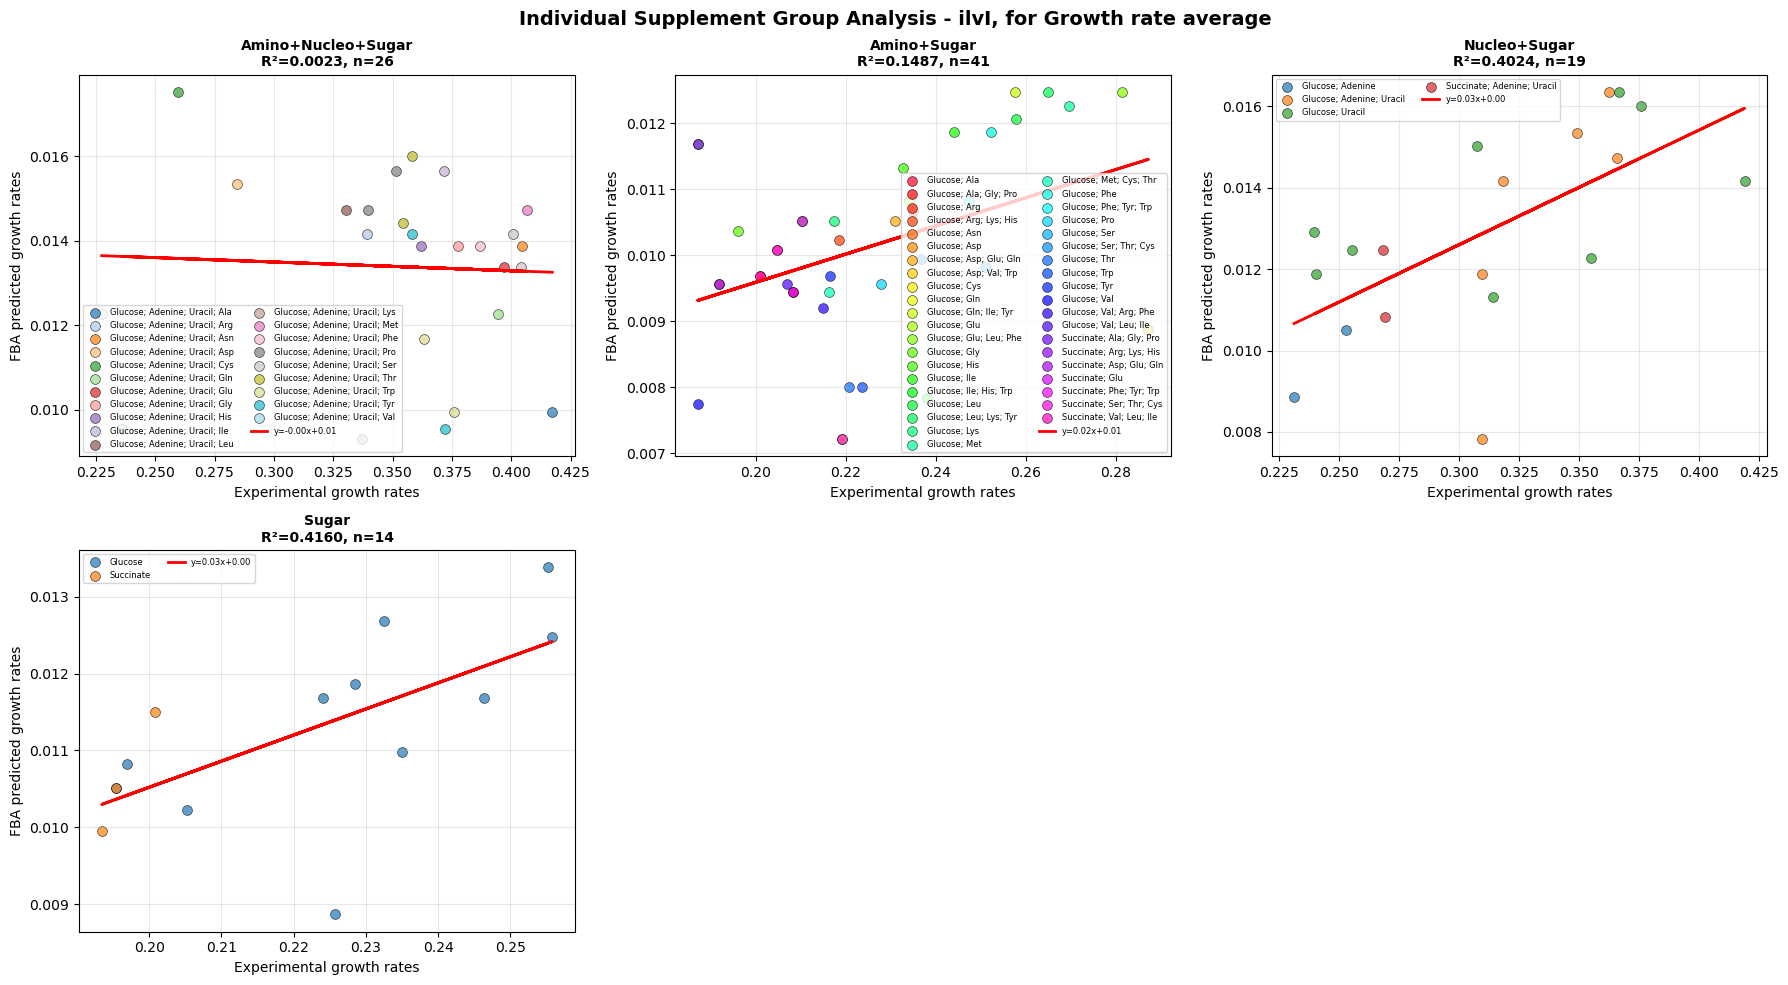

In [8]:
strains = ["WT", "SLAB", "purB", "ilvI"]
experiments = ["mediabotJLF".join(["1", "2", "3", "4", "5", "6", "7", "8", "9", "10", "11", "12", "14"])]
replications = ["no_replicates", "replicates", "post_replicates"]
gr_columns = ["mv_mu_max", "mv_mu_max", "mv_mu_max_mean"]
well_columns = ["well", "wells", "wells"]
for replication, gr_column, well_col in zip(replications, gr_columns, well_columns):
    for strain in strains:
        run(per_strain=True,
            strain=strain,
            replication=replication,
            gr_column=gr_column,
            well_column=well_col)

> The 'run_group' method is similar to 'run', execpt, by providing 'supplement_filter' argument, we can plot the dtapoint of experiments that has this supplement. Also, 'exact_match' argument controls the matching:
- exact_match = 1 : exact match on experiment supplement column
- exact_match = 2 : contains the match on experiment supplement column
- exact_match neq 1, 2 : exact match on classified supplement ("sugars", "nucleobases", "amino acides", "sugars + nucleobases", and ""sugars + nucleobases  + amino acides")

> od_cv_mean_threshold, od_cv_max_threshold, and od_std_max_threshold can filter the data based on coefficient of variability. It only applicable if the data has a column named "od600_mean", which is happens on "replicate" pipeline.

In [9]:
import cobra
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

def run_group(per_strain: bool = True,
        strain:str = "WT",
        replication:str = "no_replicates",
        gr_column:str = "mv_mu_max",
        experiment:str = "mediabotJLF2",
        supplement_filter="glucose",
        exact_match:int = 1,
        group_match:bool = False,
        well_column: str = "well",
        od_cv_mean_threshold: float = 0.0,
        od_cv_max_threshold: float = 0.0,
        od_std_max_threshold: float = 0.0,
        ):
    """
    Run FBA analysis for a specific supplement group and create detailed plots.
    
    Parameters:
    -----------
    supplement_filter : str
        The supplement to filter by (e.g., 'glucose', 'uracil', etc.)
    exact_match : int
        If True, only matches exact supplement combinations (e.g., 'glucose' won't match 'glucose; Gly')
        If False, matches any supplement containing the filter string
    """
    model = cobra.io.load_json_model("H:/ROBOT_SCIENTIST/E_coli/iML1515.json")
    
    flg_has_statistic = True
    if per_strain:
        exp_data_path = f"H:/ROBOT_SCIENTIST/E_coli/Growth_rates/2025-10-31-27/processed/{replication}_STRAINS/{strain}/AMN_dataset/"
        growth_data_path = f"H:/ROBOT_SCIENTIST/E_coli/Growth_rates/2025-10-31-27/processed/{replication}_STRAINS/{strain}/" 
        std_data_path = f"H:/ROBOT_SCIENTIST/E_coli/Growth_rates/2025-10-31-27/processed/{replication}/"
        directories = [d for d in Path(std_data_path).iterdir()]
        std_data_list = [ pd.read_csv(d / "predictions.csv") for d in directories if (d / "predictions.csv").exists() ]        
        for df , d in zip(std_data_list, directories):
            if "od600_mean" not in df.columns:
                flg_has_statistic = False
                break
            df["experiment"] = d.name
            # Coefficient of Variation (CV), also known as Relative Standard Deviation (RSD).
            df["od_CV"] = df['od600_std'] / df['od600_mean']


        if flg_has_statistic:
            std_data = pd.concat(std_data_list, ignore_index=True)        
            std_data = std_data.groupby([well_column,"experiment"]).agg(
                od_mean_max = ( 'od600_mean', 'max' ),
                od_mean_mean = ( 'od600_mean', 'mean' ),
                od_std_max = ( 'od600_std', 'max' ),
                od_std_mean = ( 'od600_std', 'mean' ),
                od_cv_max = ('od_CV', 'max'),
                od_cv_mean = ('od_CV', 'mean'),
            ).reset_index()                  

    else:
        exp_data_path = f"H:/ROBOT_SCIENTIST/E_coli/Growth_rates/2025-10-31-27/processed/{replication}/{experiment}/AMN_dataset/"
        growth_data_path = f"H:/ROBOT_SCIENTIST/E_coli/Growth_rates/2025-10-31-27/processed/{replication}/{experiment}/"

        std_data = pd.read_csv(growth_data_path + "predictions.csv") 
        if "od600_mean" not in std_data.columns:
            flg_has_statistic = False       
            std_data = std_data.groupby(well_column).agg(
                od_mean_max = ( 'od600_mean', 'max' ),
                od_mean_mean = ( 'od600_mean', 'mean' ),
                od_std_max = ( 'od600_std', 'max' ),
                od_std_mean = ( 'od600_std', 'mean' ),
            ).reset_index()
    # 
    exp_data = pd.read_csv(exp_data_path + "df_flux.csv") 
    growth_data = pd.read_csv(growth_data_path + "growth_rates.csv")
    
    # Filter growth_data to match the rows in exp_data 
    growth_data = growth_data.reset_index(drop=True)
    growth_data = growth_data.loc[growth_data['success'], :]
    exp_data = exp_data.reset_index(drop=True)        
    # Remove growth rate column from growth_data to avoid duplicates
    growth_data = growth_data.drop(columns=[gr_column])                
    # Now join them - they should have the same number of rows
    combinded_data = pd.concat([exp_data.reset_index(drop=True), growth_data.reset_index(drop=True)],
                                axis=1)
        
    if flg_has_statistic:
        if per_strain:
            combinded_data = combinded_data.merge(std_data, on=["experiment", well_column], how="left")
        else:
            combinded_data = combinded_data.merge(std_data, on=[well_column], how="left")

    if flg_has_statistic and od_cv_mean_threshold > 0.0:        
        combinded_data = combinded_data.loc[combinded_data["od_cv_mean"] <= od_cv_mean_threshold, :].copy().reset_index(drop=True)
        exp_data = combinded_data[exp_data.columns]
        if combinded_data.shape[0] < 2:
            print("Not enough data.")
            return
    elif flg_has_statistic and od_cv_max_threshold > 0.0:
        combinded_data = combinded_data.loc[combinded_data["od_cv_max"] <= od_cv_max_threshold, :].copy().reset_index(drop=True)
        exp_data = combinded_data[exp_data.columns]
        if combinded_data.shape[0] < 2:
            print("Not enough data.")
            return
    elif flg_has_statistic and od_std_max_threshold > 0.0:
        combinded_data = combinded_data.loc[combinded_data["od_std_max"] <= od_std_max_threshold, :].copy().reset_index(drop=True)
        exp_data = combinded_data[exp_data.columns]
        if combinded_data.shape[0] < 2:
            print("Not enough data.")
            return

    def update_uracil(val):
        for part in ["_0.5", "_22.4", "_200", "_2", "_8", "_64", "_640", "0"]:
             val = val.replace(part, "")
        return val
    combinded_data["supplements_unified"] = combinded_data["supplements"].apply(lambda x: update_uracil(str(x)) if pd.notna(x) else x)
    
    def classify(val):
        """Classify supplements into Sugar, Nucleo, Amino based on content"""
        if pd.isna(val) or str(val).lower() == 'nan' or str(val).strip() == '':
            return 'None'
        
        # Split by semicolon and convert to lowercase for comparison
        parts = str(val).lower().split(';')
        parts = [p.strip() for p in parts if p.strip()]
        
        if not parts:
            return 'None'
        
        # Define categories (all lowercase)
        sugars = ['glucose', 'succinate', 'sucrose', 'galactose', 'fructose', 'mannose',
                  'maltose', 'lactose', 'xylose', 'arabinose', 'ribose']
        
        nucleobases = ['adenine', 'uracil', 'guanine', 'cytosine', 'thymine']
        
        # Amino acids are typically 3 letters (all lowercase)
        amino_acids_3letter = ['ala', 'arg', 'asn', 'asp', 'cys', 'gln', 'glu', 'gly',
                               'his', 'ile', 'leu', 'lys', 'met', 'phe', 'pro', 'ser',
                               'thr', 'trp', 'tyr', 'val']
        
        categories = []
        for part in parts:
            # Check if it's a sugar
            if any(sugar in part for sugar in sugars):
                if 'Sugar' not in categories:
                    categories.append('Sugar')
            # Check if it's a nucleobase
            elif any(nucleo in part for nucleo in nucleobases):
                if 'Nucleo' not in categories:
                    categories.append('Nucleo')
            # Check if it's a 3-letter amino acid or contains common amino acid patterns
            elif any(aa in part for aa in amino_acids_3letter) or len(part) == 3:
                if 'Amino' not in categories:
                    categories.append('Amino')
        
        if not categories:
            return 'Other'
        
        # Sort to ensure consistent ordering
        categories.sort()
        return '+'.join(categories)
    
    combinded_data["group"] = combinded_data["supplements_unified"].apply(classify)
    
    # FILTER DATA BEFORE FBA - This is the key fix!
    if exact_match == 1:
        # Exact match: case-insensitive comparison of the entire supplement string
        supplement_mask = combinded_data['supplements_unified'].astype(str).str.lower() == supplement_filter.lower()
    elif exact_match == 2:
        # Contains match: finds any supplement containing the filter string
        supplement_mask = combinded_data['supplements_unified'].astype(str).str.lower().str.contains(supplement_filter.lower(), na=False)
    elif group_match:
        supplement_mask = combinded_data['group'].astype(str).str.lower() == supplement_filter.lower()
    
    if not supplement_mask.any():
        match_type = "exactly matching" if exact_match else "containing"
        print(f"No data found for supplement {match_type} '{supplement_filter}'")
        return
    
    # Filter both exp_data and combinded_data
    exp_data_filtered = exp_data[supplement_mask].reset_index(drop=True)
    combinded_data_filtered = combinded_data[supplement_mask].reset_index(drop=True)
    
    match_type = "exact matches" if exact_match else "samples containing"
    print(f"Running FBA for {len(exp_data_filtered)} {match_type} '{supplement_filter}'")
    
    #===============================
    # Run FBA only on filtered data
    preds = []
    status = []
    for _, row in exp_data_filtered.iterrows():
        with model:
            # Set the medium according to the experimental data
            medium = model.medium.copy()
            for rxn_id in medium:
                medium[rxn_id] = 0.0  # Set high uptake rates for all exchange reactions
            for rxn_id in exp_data_filtered.columns:
                if rxn_id != gr_column:
                    medium[rxn_id] = row.get(rxn_id, 0.0)  # Set uptake rates based on experimental data
            model.medium = medium
            # Perform FBA
            model.objective = 'BIOMASS_Ec_iML1515_core_75p37M'                
            solution = model.optimize()        
            preds.append(solution.objective_value)
            status.append(solution.status  == 'optimal')
    
    # Remove outliers from predictions
    preds_array = np.array(preds)
    status_array = np.array(status)
    percentile_lower = 0
    percentile_upper = 100
    q1 = np.percentile(preds_array, percentile_lower)
    q3 = np.percentile(preds_array, percentile_upper)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    filtered_preds = [pred if lower_bound <= pred <= upper_bound else np.nan for pred in preds_array]
    filtered_status = [status_array[i] if lower_bound <= preds_array[i] <= upper_bound else False for i in range(len(preds_array))]
    
    masks = [s for s in filtered_status]
    
    # Get filtered data for plotting
    y = np.array([p for p, m in zip(filtered_preds, masks) if m])
    x = np.array(combinded_data_filtered[gr_column][masks])
    
    # Get individual supplements for color coding
    supplements = combinded_data_filtered['supplements_unified'][masks].values
    unique_supps = np.unique(supplements)
    n_supps = len(unique_supps)
    
    # Create color map - same logic as in run()
    if n_supps <= 10:
        colors = plt.cm.tab10(np.linspace(0, 1, 10))[:n_supps]
    elif n_supps <= 20:
        colors = plt.cm.tab20(np.linspace(0, 1, 20))[:n_supps]
    else:
        colors = plt.cm.gist_rainbow(np.linspace(0, 1, n_supps))
    
    supp_colors = {supp: colors[i] for i, supp in enumerate(unique_supps)}
    
    # Create figure with 3 subplots
    fig = plt.figure(figsize=(16, 6))
    ax1, ax2, ax3 = fig.subplots(1, 3)
    
    # Plot each supplement with its own color
    for supp in unique_supps:
        supp_mask = supplements == supp
        ax1.scatter(x[supp_mask], y[supp_mask], 
                   color=supp_colors[supp], 
                   label=supp, 
                   alpha=0.7, 
                   s=50,
                   edgecolors='black',
                   linewidths=0.5)
    
    # Regression line
    m, b = np.polyfit(x, y, 1)
    ax1.plot(x, m*x + b, color='red', linewidth=2, label=f'y={m:.2f}x+{b:.2f}')
    
    # Calculate R²
    correlation_matrix = np.corrcoef(x, y)
    correlation_xy = correlation_matrix[0, 1]
    r_squared = correlation_xy**2
    
    ax1.set_xlabel("Experimental growth rates")
    ax1.set_ylabel("FBA predicted growth rates")
    if per_strain:
        subtitle = f"Strain:{strain}, Supplement:{supplement_filter}\nData points n:{len(x)}"
    else:
        subtitle = f"Experiment:{experiment}, Supplement:{supplement_filter}\nData points n:{len(x)}"
    ax1.set_title(f"(R²={r_squared:.4f})\n{subtitle}")
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, 
              title='Supplement', framealpha=0.9)
    ax1.grid(True, alpha=0.3)
    
    #==========================
    # Residuals plot
    residuals = y - (m * x + b)
    for supp in unique_supps:
        supp_mask = supplements == supp
        ax2.scatter(x[supp_mask], residuals[supp_mask], 
                   color=supp_colors[supp], 
                   alpha=0.7,
                   s=50,
                   edgecolors='black',
                   linewidths=0.5)
    ax2.axhline(0, color='red', linestyle='--', linewidth=2)
    ax2.set_xlabel("Experimental growth rates")
    ax2.set_ylabel("Residuals (Predicted - Experimental)")
    ax2.set_title("Residuals Plot")
    ax2.grid(True, alpha=0.3)
    
    #==========================
    # Residual distribution histogram
    ax3.hist([residuals[supplements == supp] for supp in unique_supps],
             label=[str(supp) for supp in unique_supps],
             color=[supp_colors[supp] for supp in unique_supps],
             alpha=0.7,
             edgecolor='black',
             linewidth=0.5,
             stacked=False)
    ax3.legend(fontsize=8, title='Supplement')
    ax3.set_xlabel("Residuals")
    ax3.set_ylabel("Frequency")
    ax3.set_title("Residuals Distribution")
    
    #==========================
    match_type_label = "Exact Match" if exact_match else "Contains"
    average_type = "All data points" if replication == "no_replicates" else "OD average" if replication == "replicates" else "Growth rate average"
    plt.suptitle(f"FBA Analysis for '{supplement_filter}' ({match_type_label}) - {average_type}", 
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


### Plotting supplement that are only "glucose" or "succinate". You can change it based on your preferences.

Running FBA for 22 exact matches 'glucose'


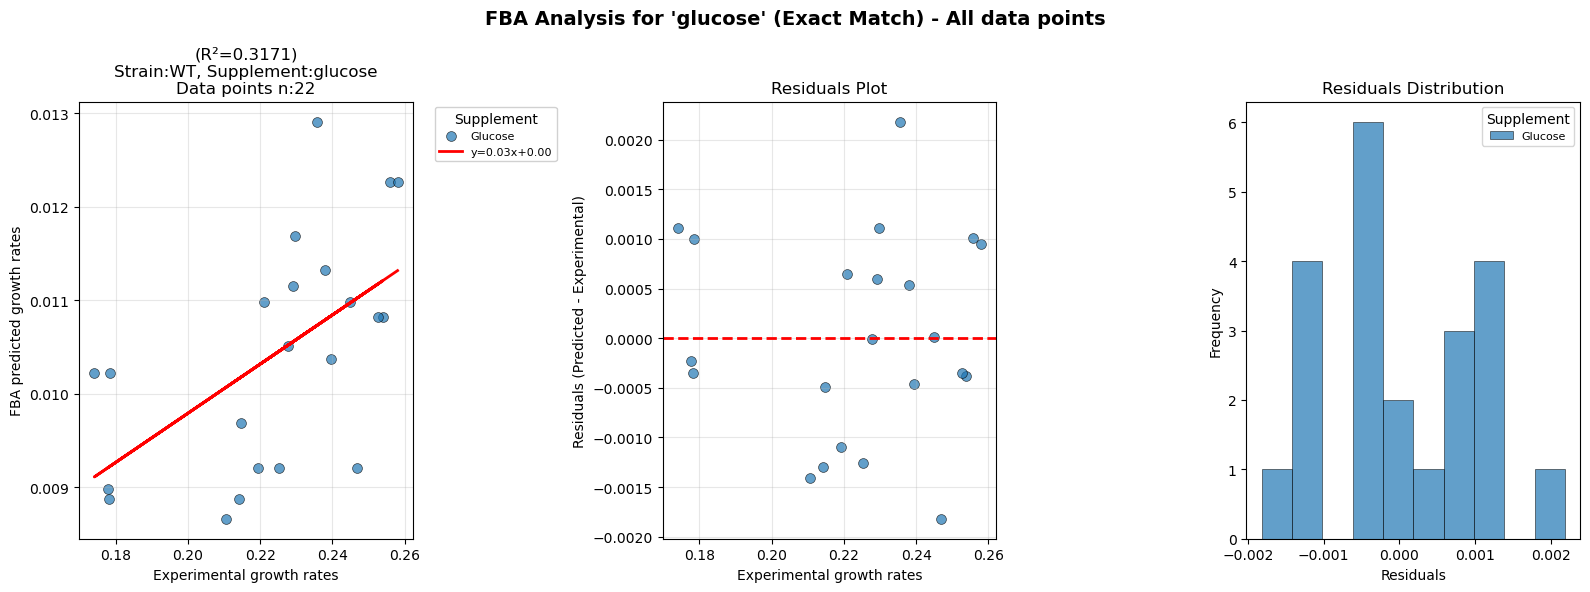

Running FBA for 6 exact matches 'succinate'


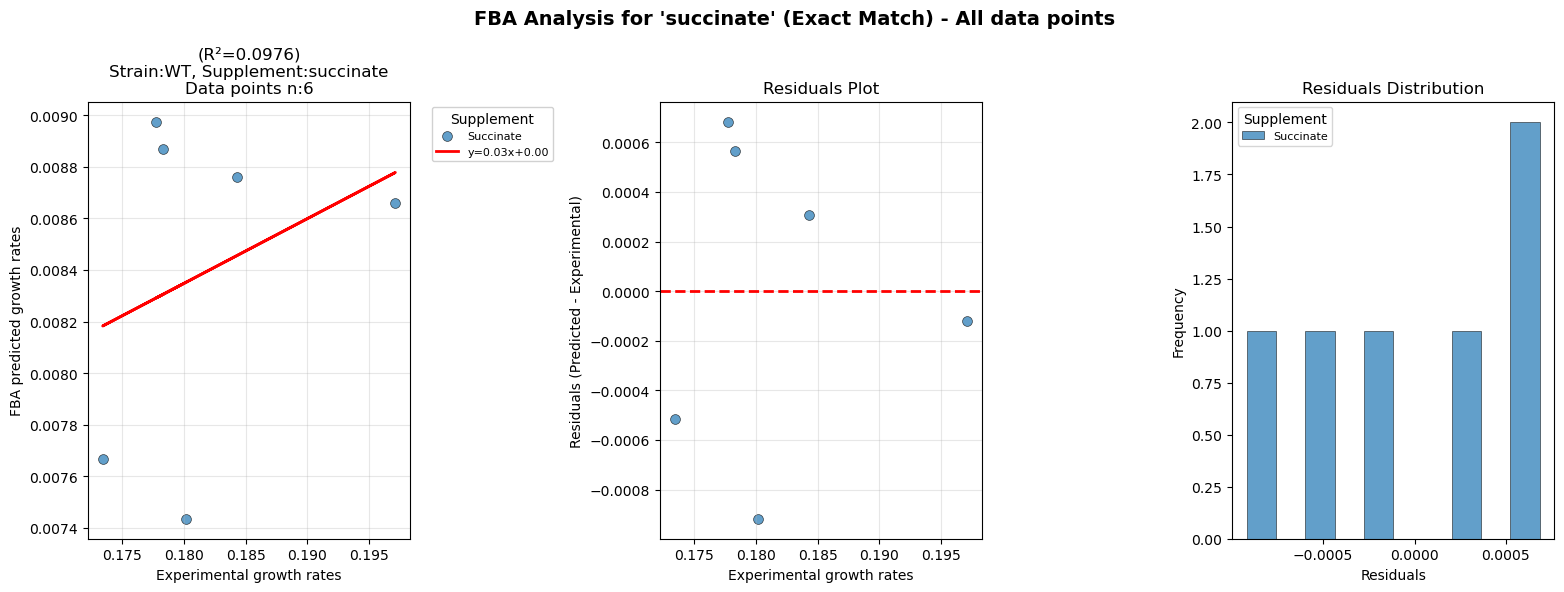

Running FBA for 33 exact matches 'glucose'


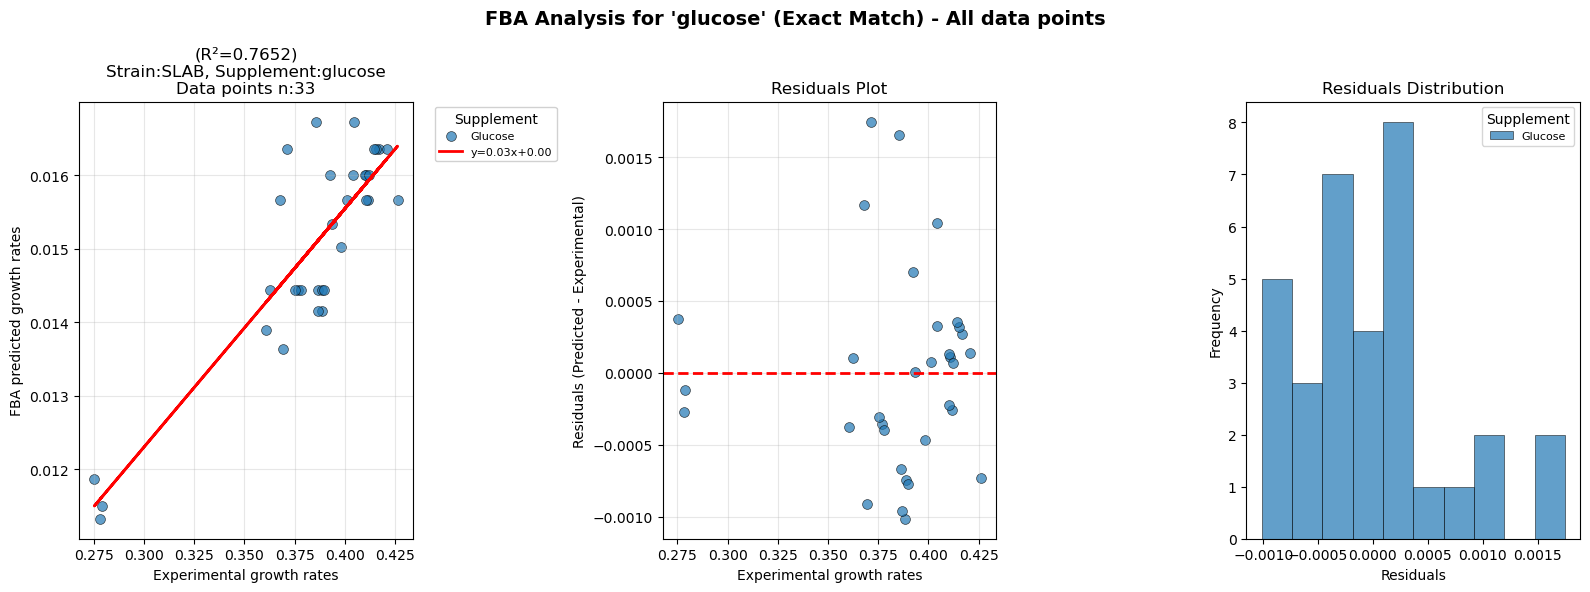

Running FBA for 9 exact matches 'succinate'


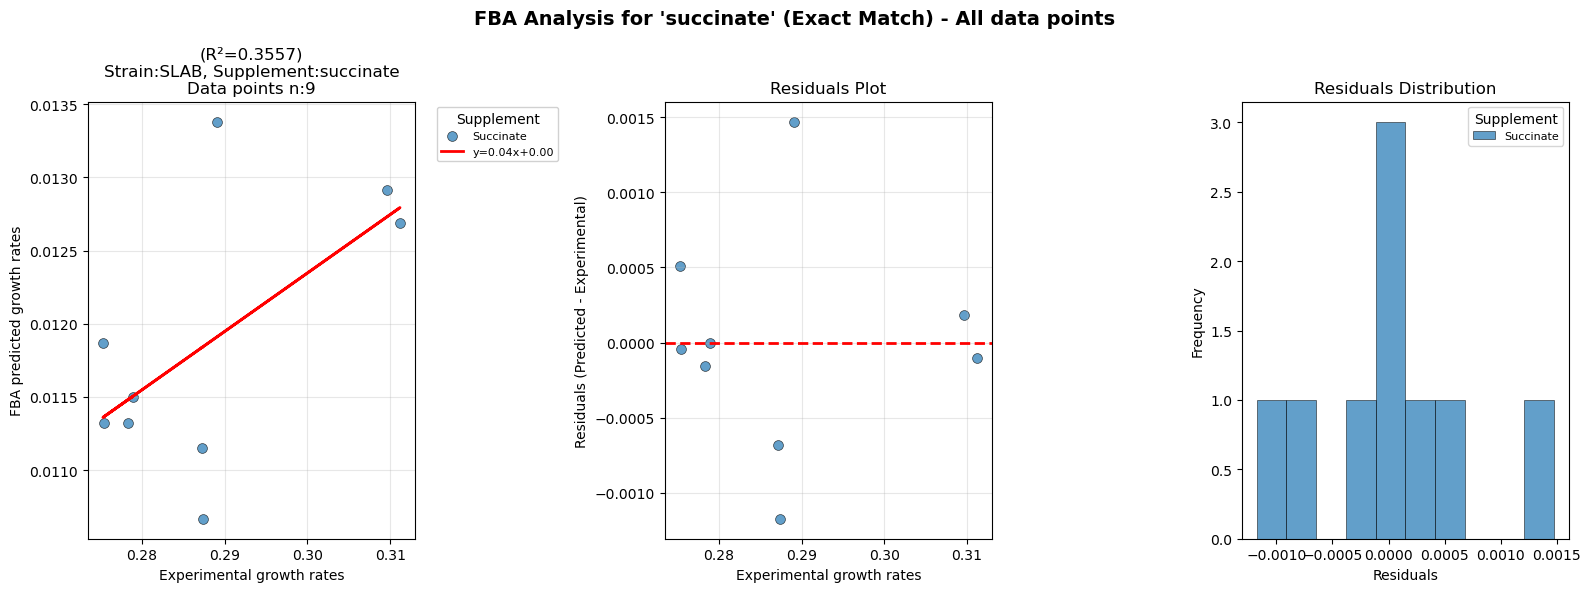

Running FBA for 33 exact matches 'glucose'


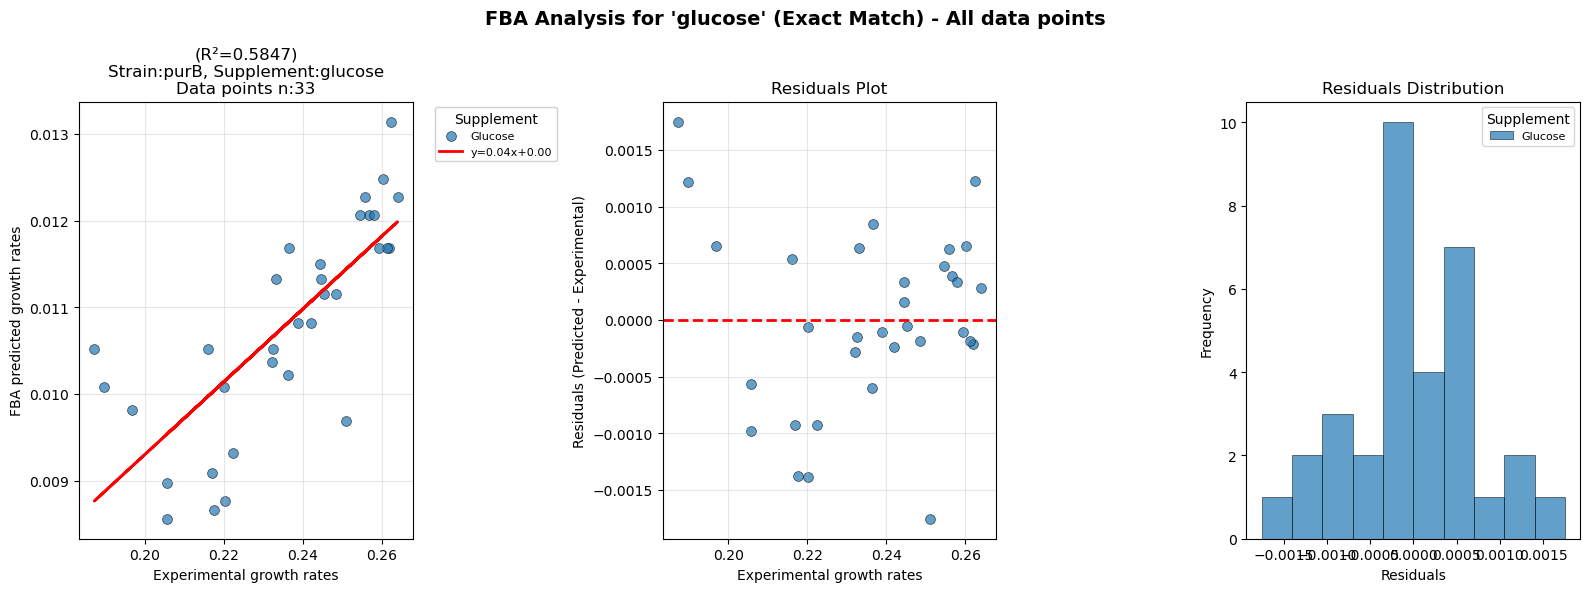

Running FBA for 8 exact matches 'succinate'


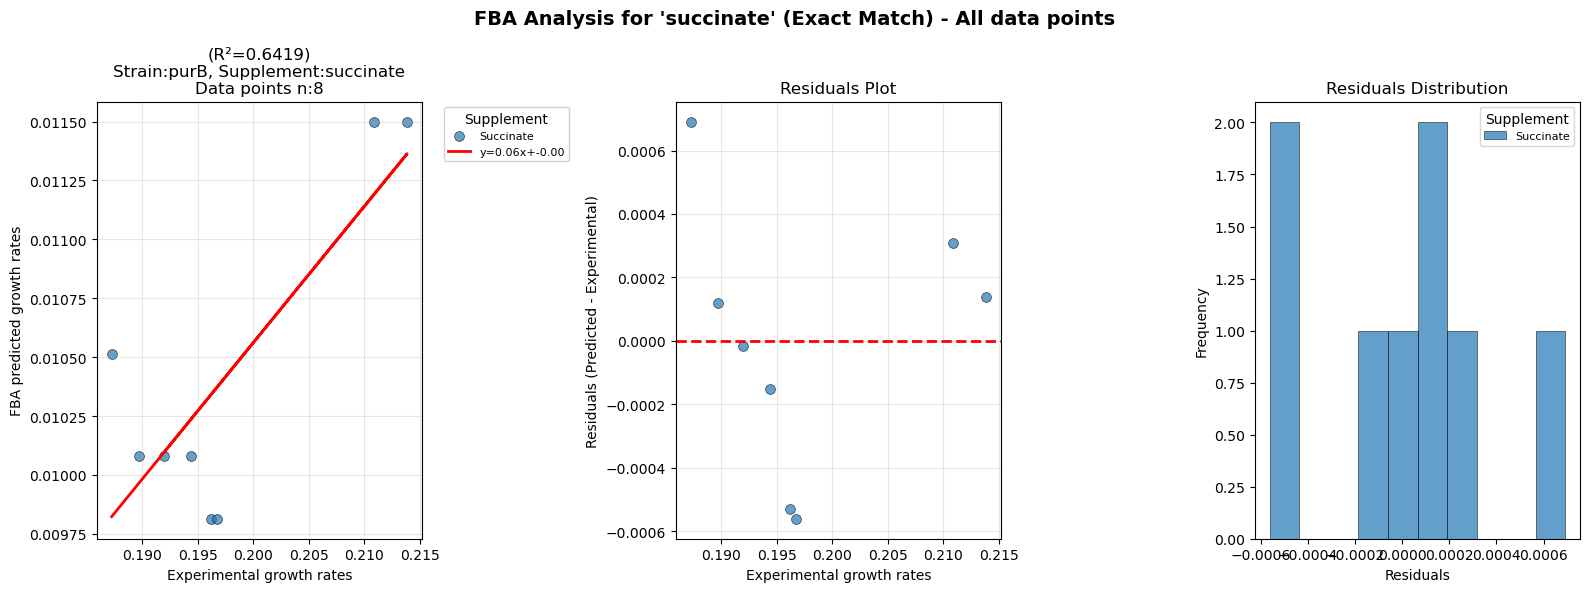

Running FBA for 33 exact matches 'glucose'


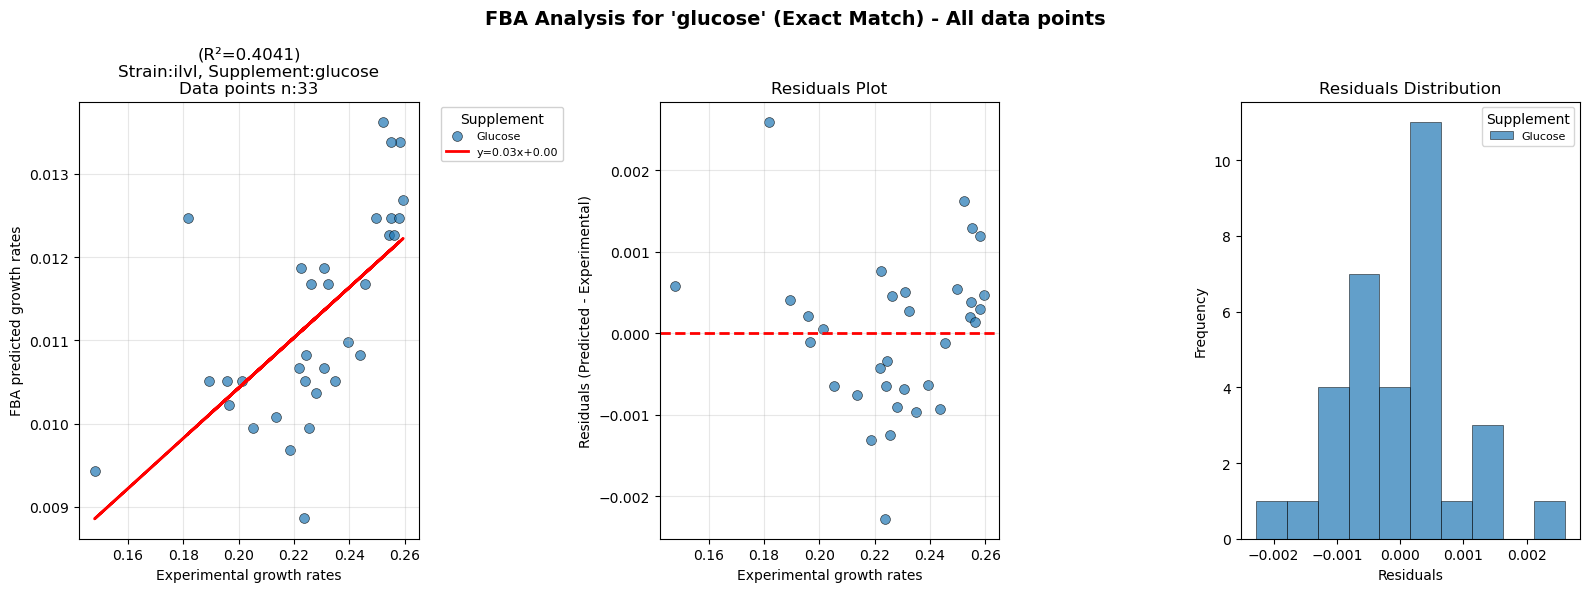

Running FBA for 9 exact matches 'succinate'


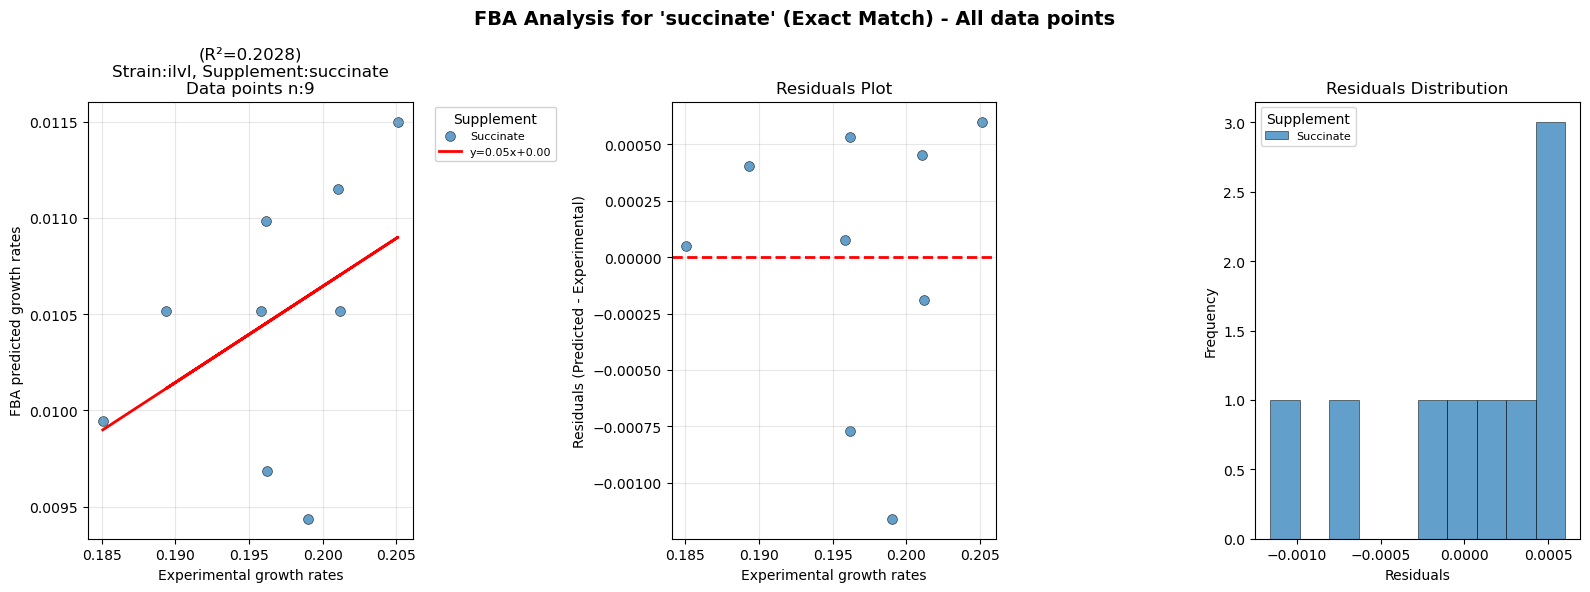

Running FBA for 11 exact matches 'glucose'


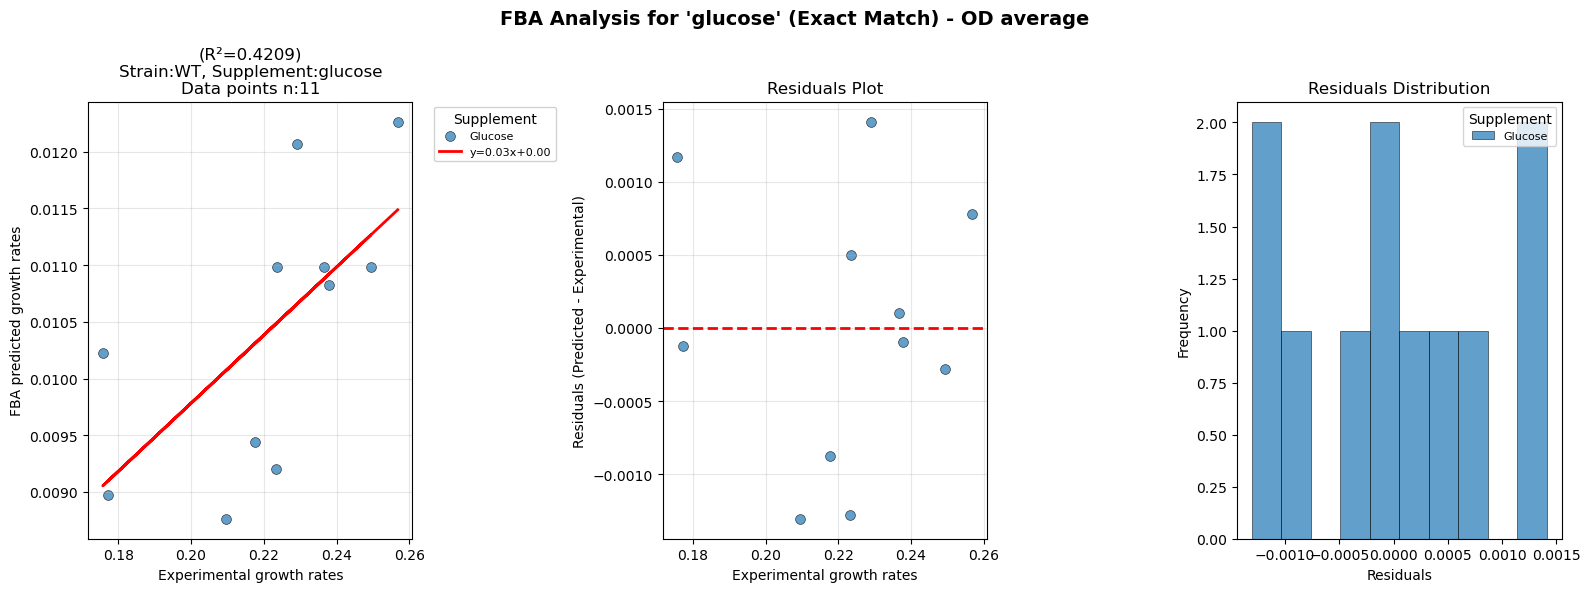

Running FBA for 3 exact matches 'succinate'


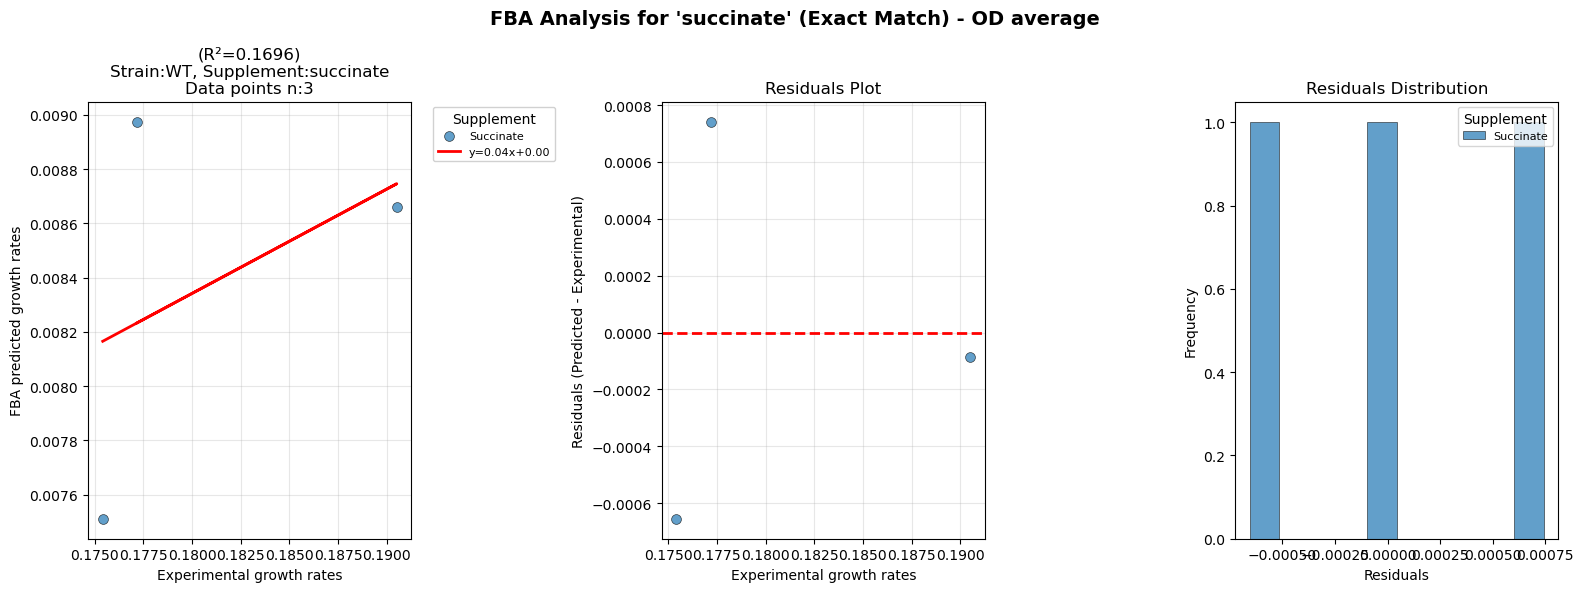

Running FBA for 11 exact matches 'glucose'


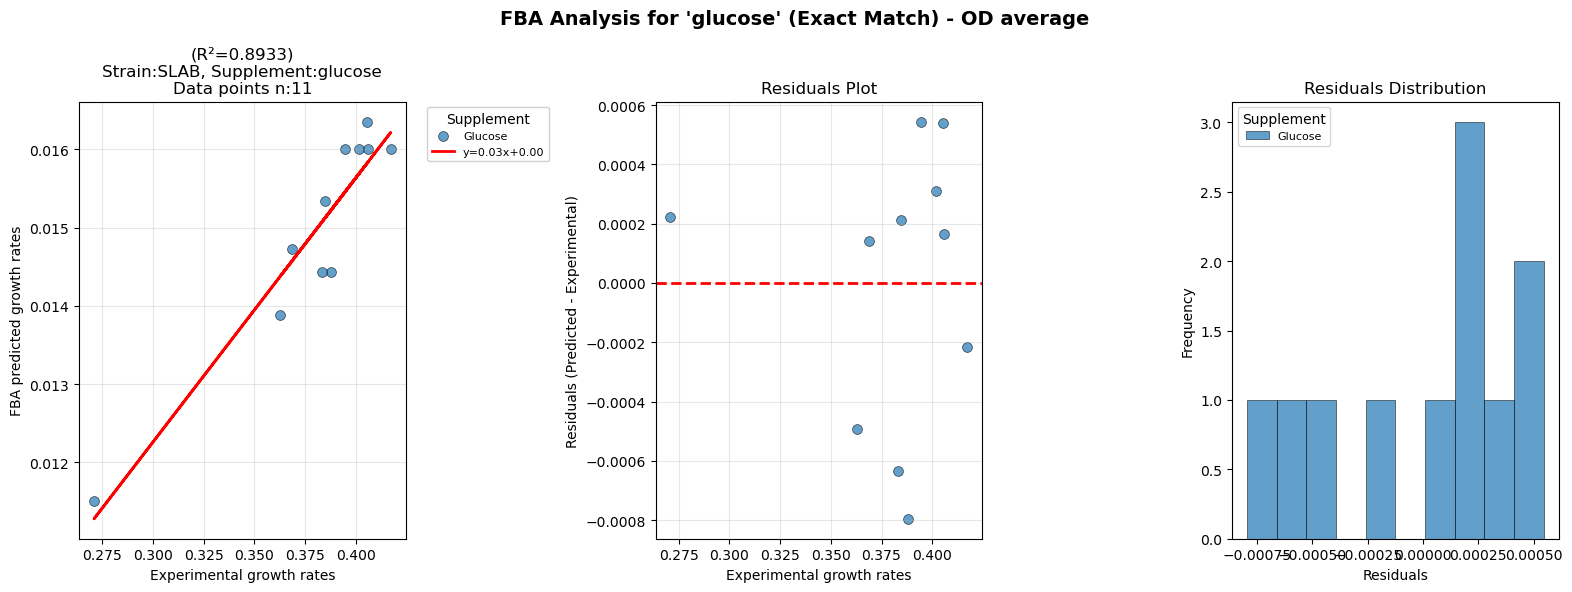

Running FBA for 3 exact matches 'succinate'


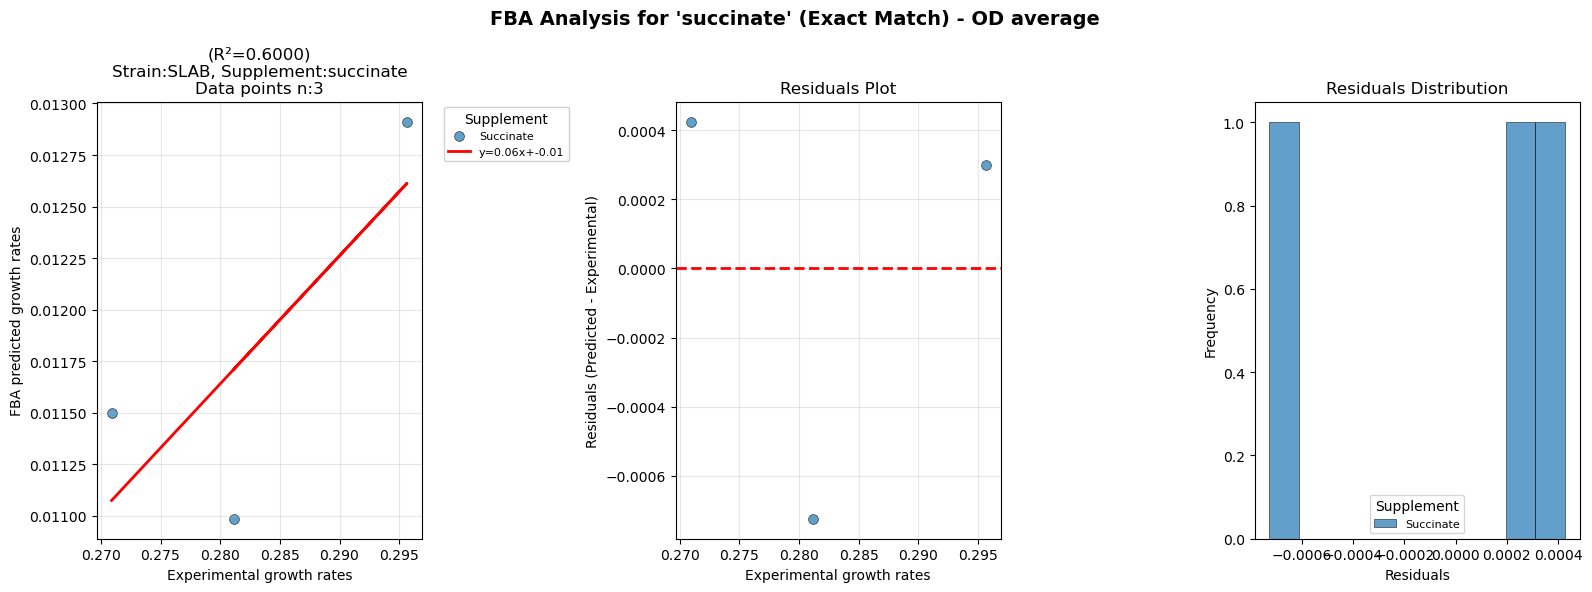

Running FBA for 11 exact matches 'glucose'


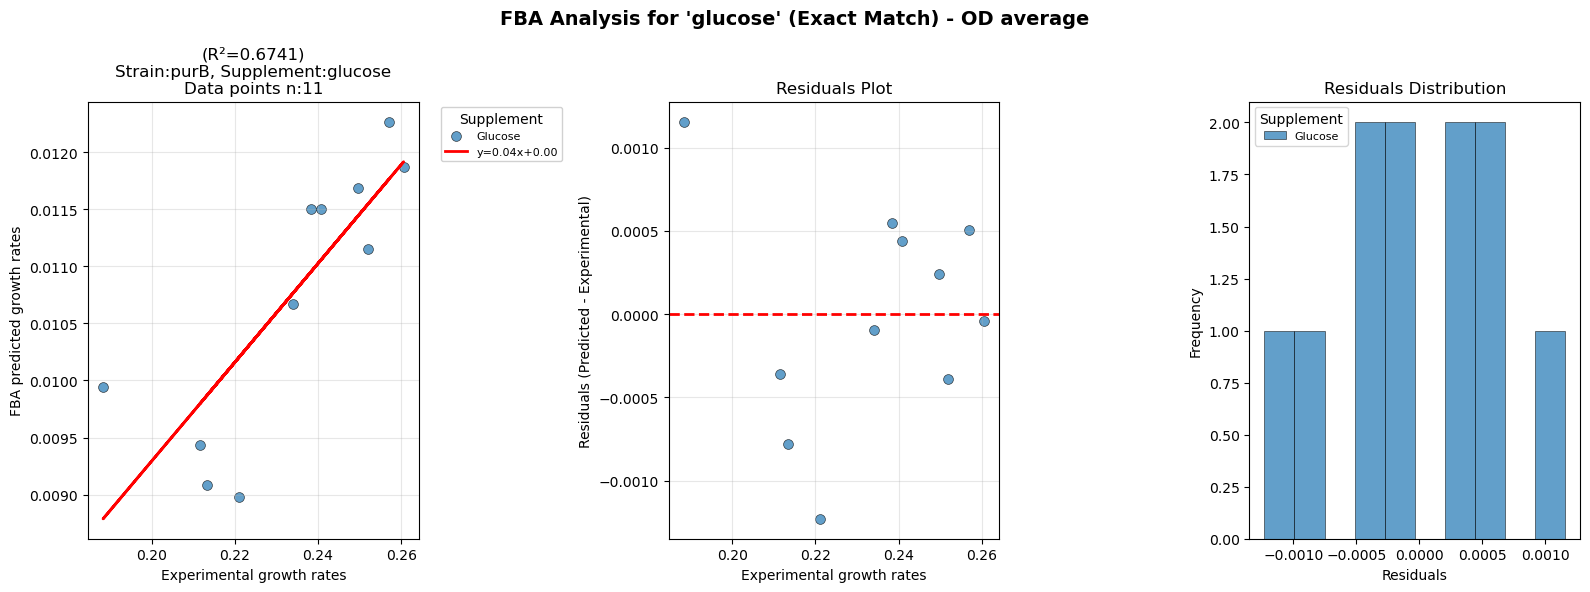

Running FBA for 3 exact matches 'succinate'


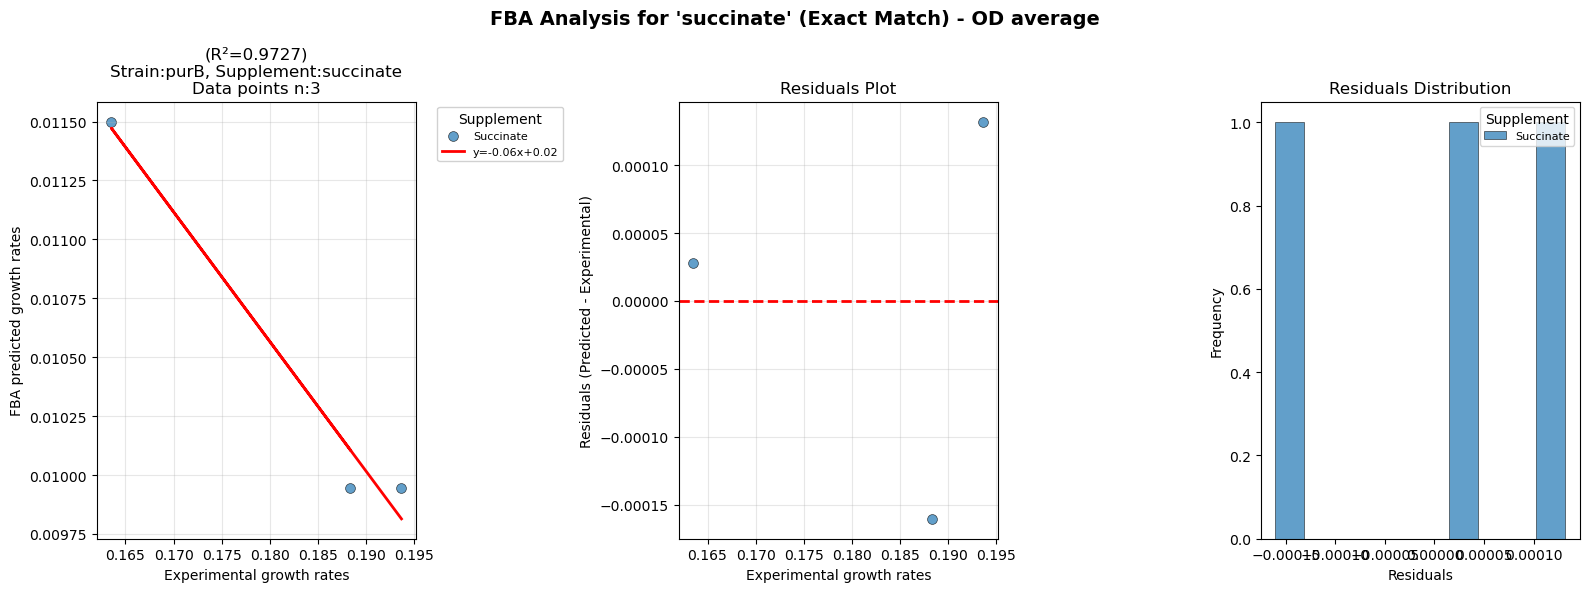

Running FBA for 11 exact matches 'glucose'


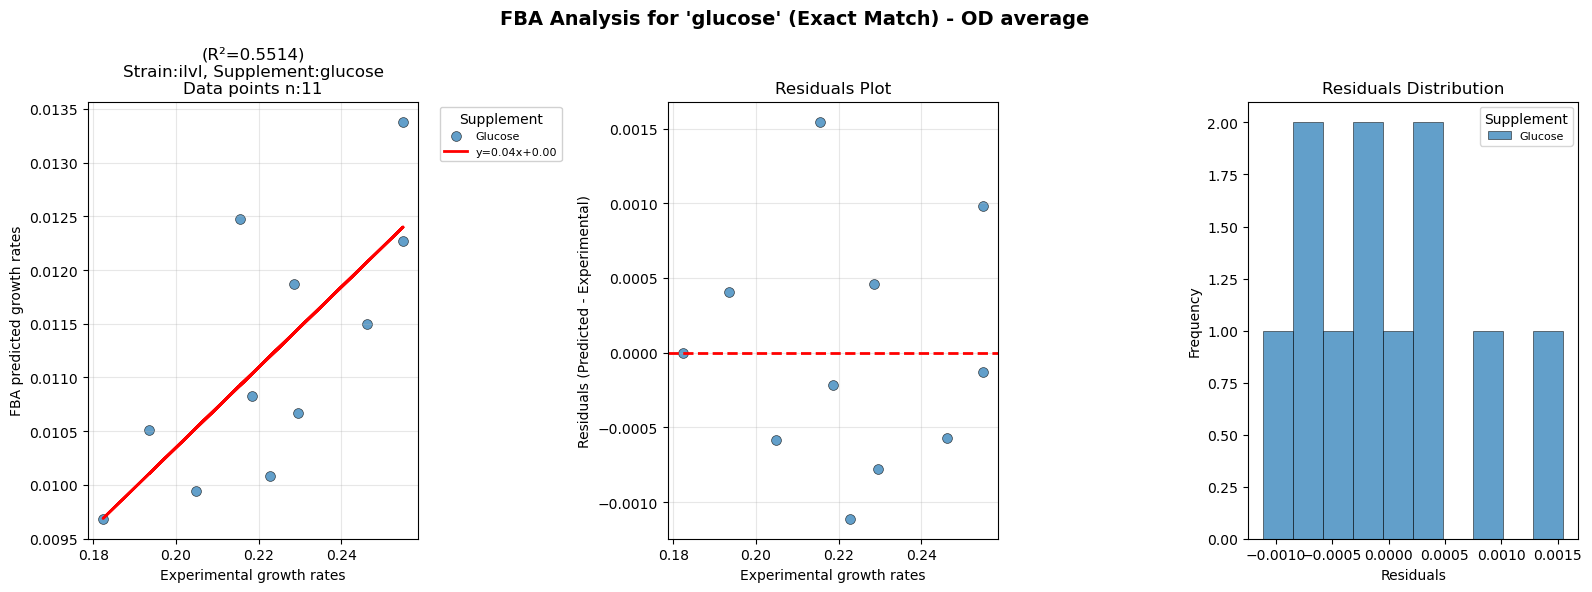

Running FBA for 3 exact matches 'succinate'


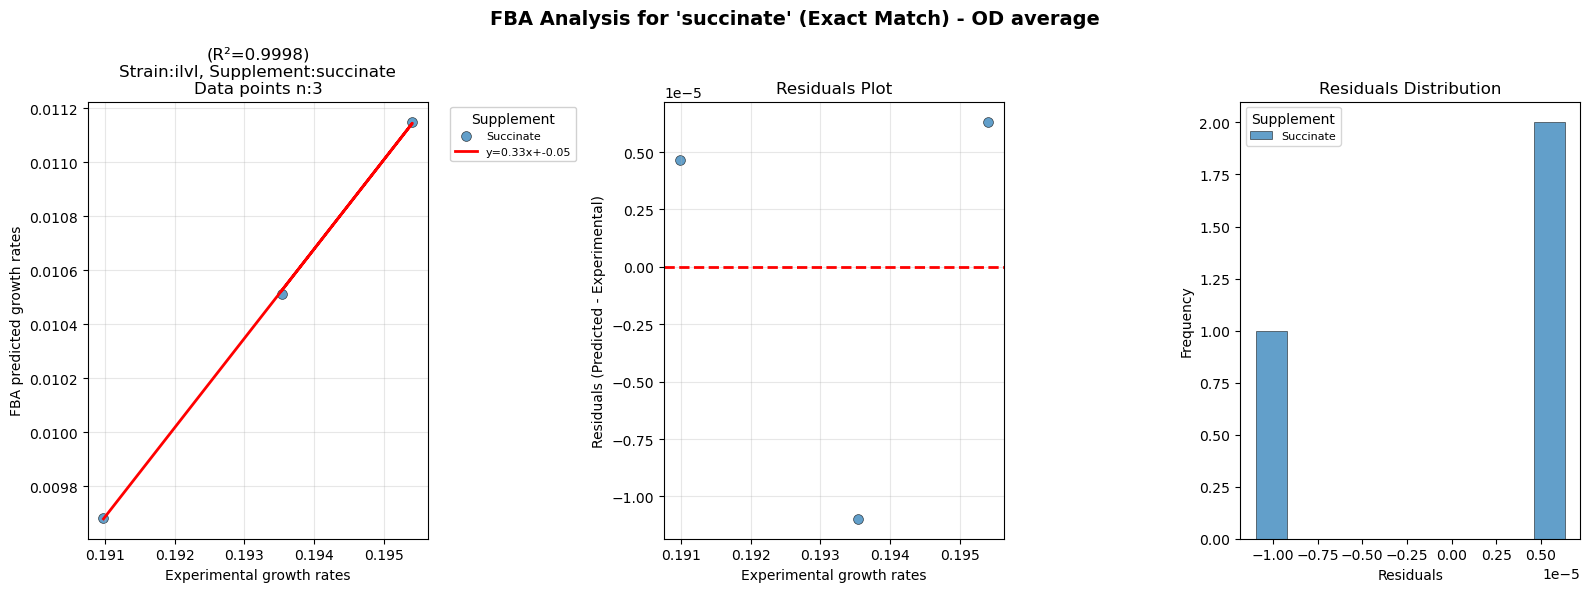

Running FBA for 11 exact matches 'glucose'


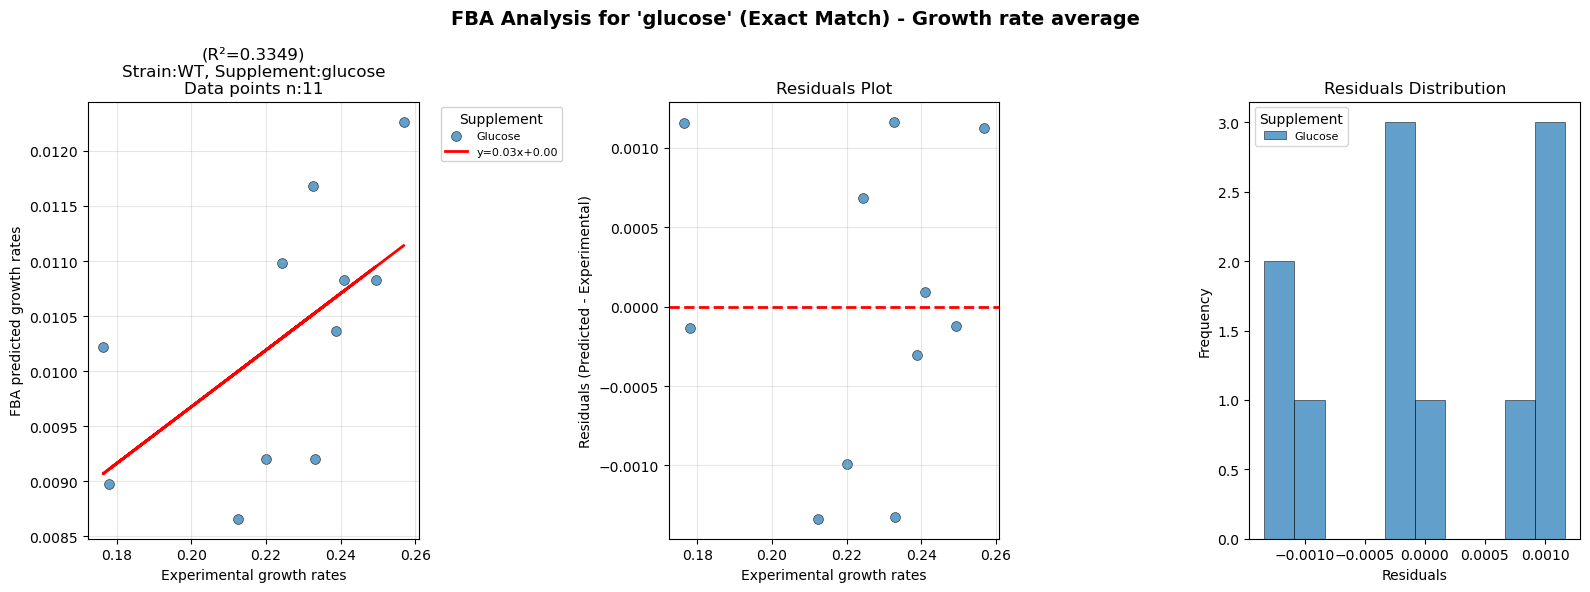

Running FBA for 3 exact matches 'succinate'


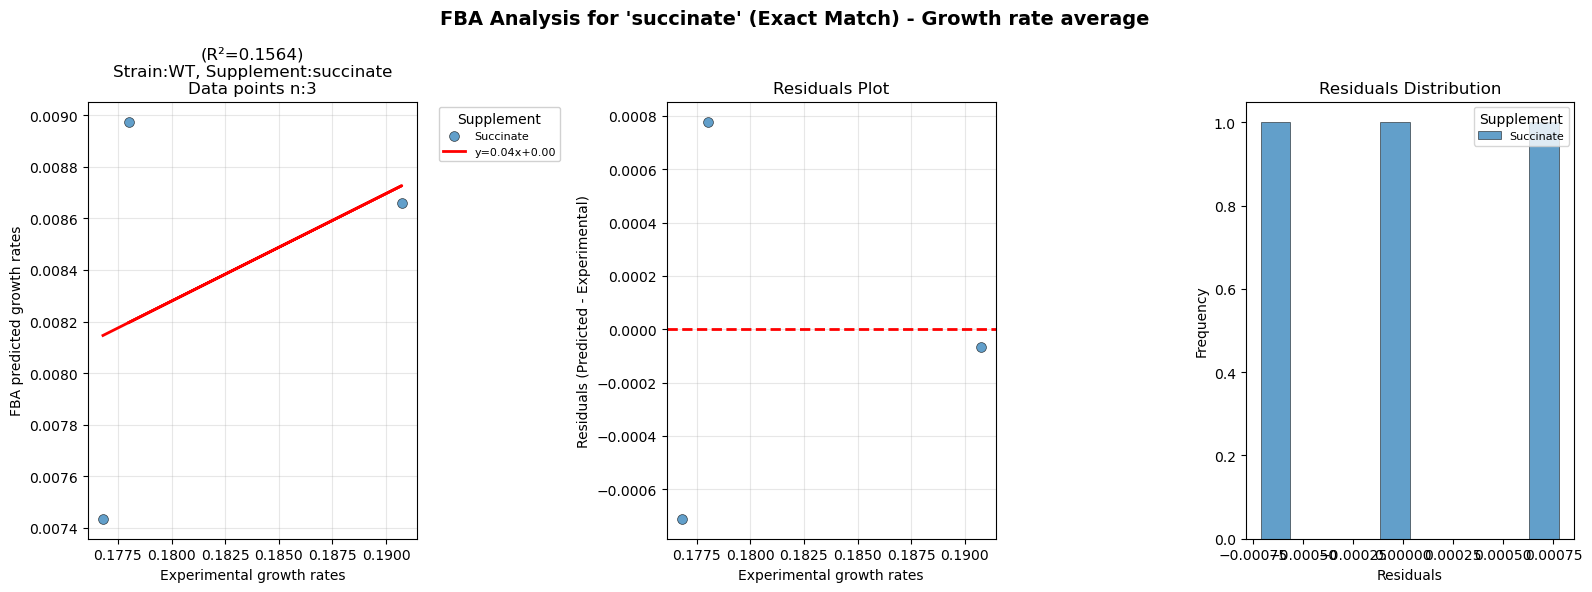

Running FBA for 11 exact matches 'glucose'


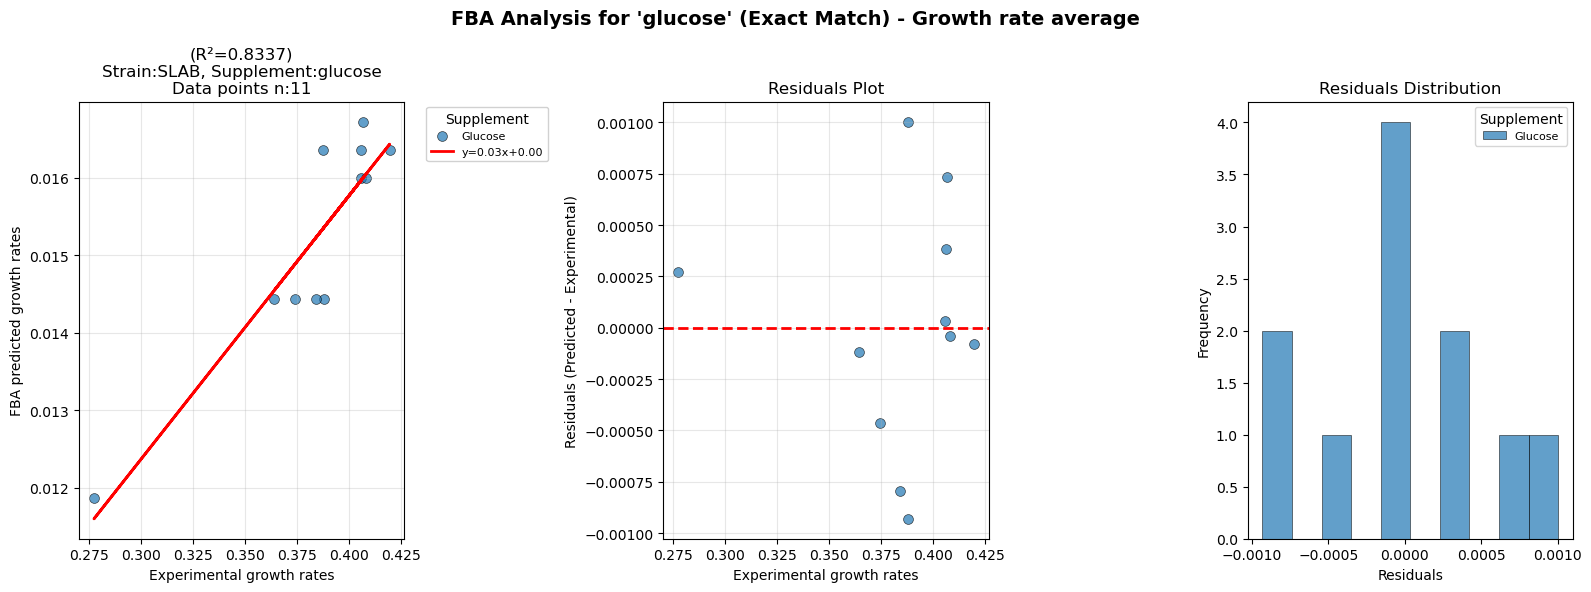

Running FBA for 3 exact matches 'succinate'


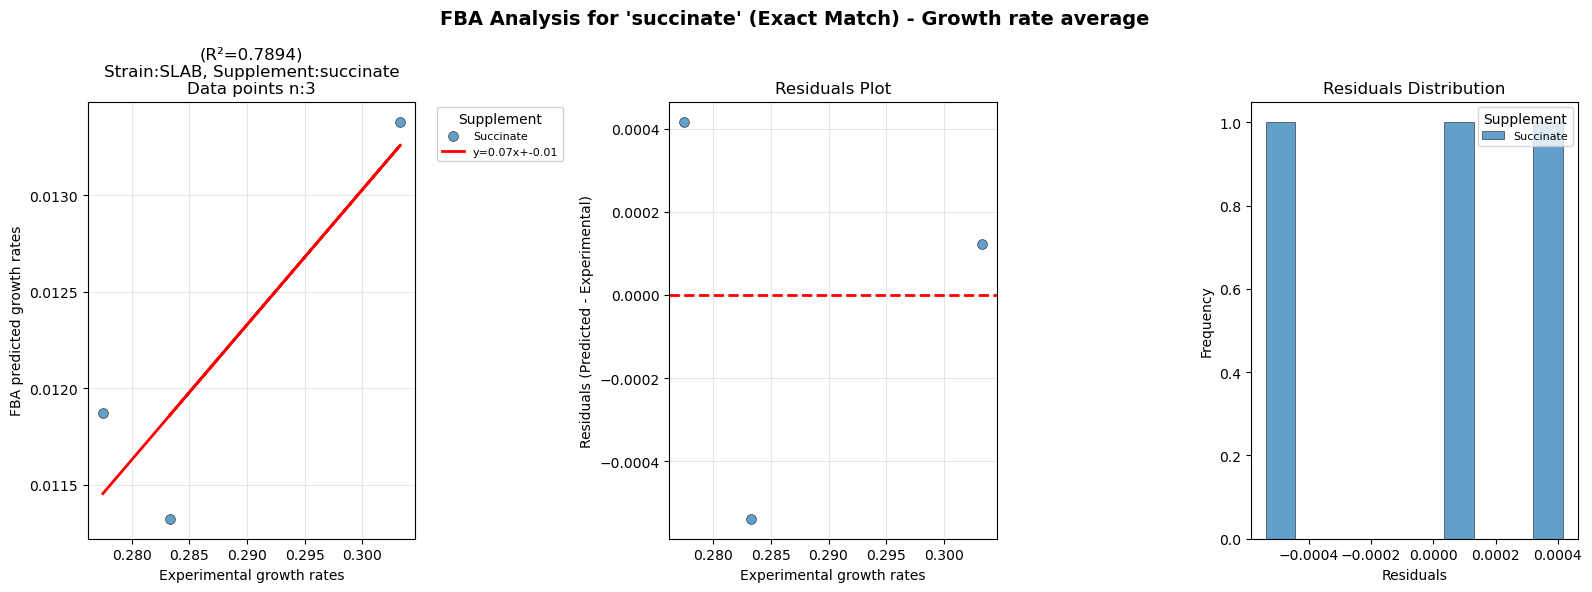

Running FBA for 11 exact matches 'glucose'


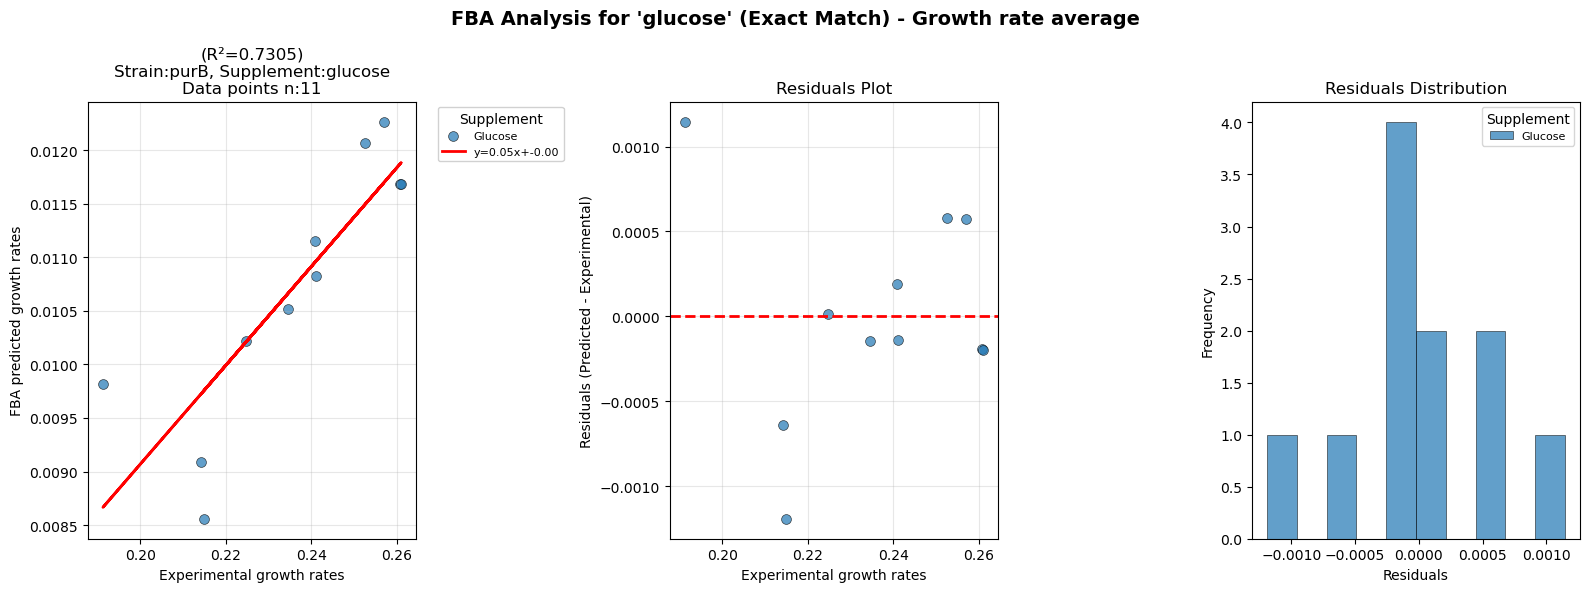

Running FBA for 2 exact matches 'succinate'


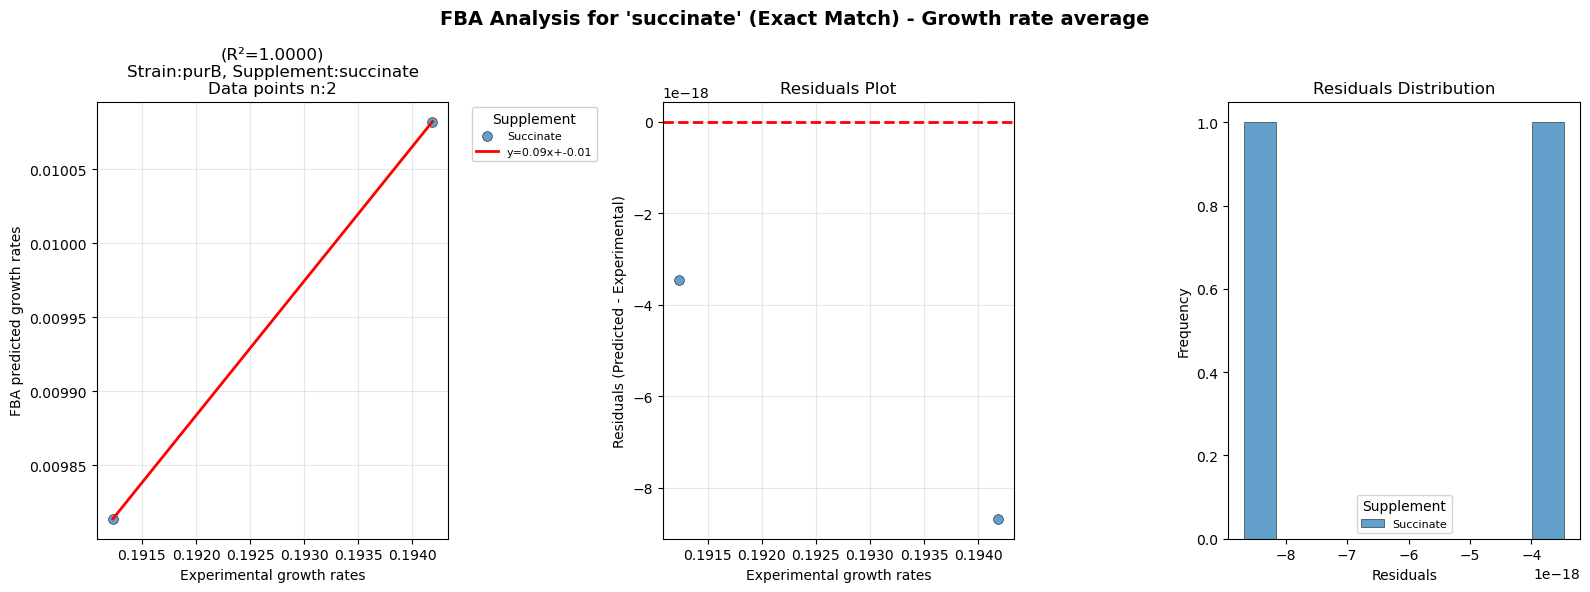

Running FBA for 11 exact matches 'glucose'


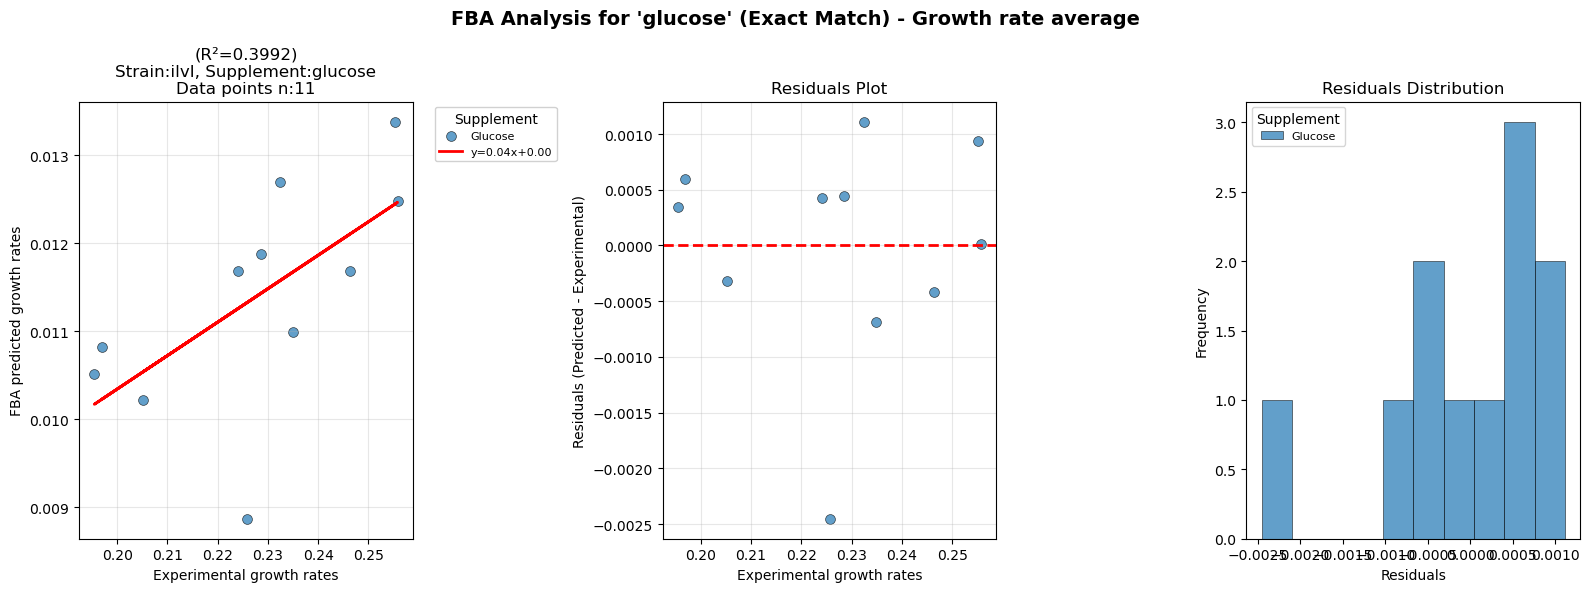

Running FBA for 3 exact matches 'succinate'


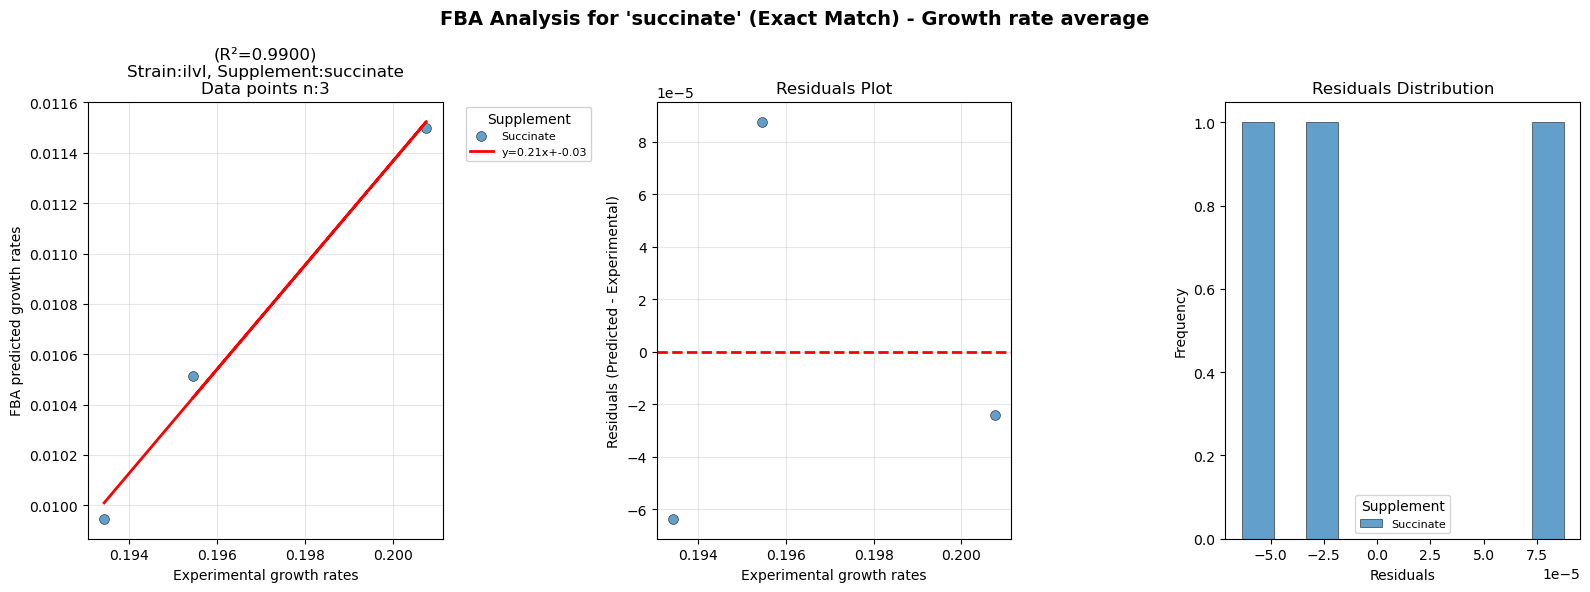

In [10]:
strains = ["WT", "SLAB", "purB", "ilvI"]
experiments = ["mediabotJLF".join(["1", "2", "3", "4", "5", "6", "7", "8", "9", "10", "11", "12", "14"])]
replications = ["no_replicates", "replicates", "post_replicates"]
gr_columns = ["mv_mu_max", "mv_mu_max", "mv_mu_max_mean"]
well_columns = ["well", "wells", "wells"]
for replication, gr_column, well_column in zip(replications, gr_columns, well_columns):
    for strain in strains:
        run_group(per_strain=True,
            strain=strain,
            replication=replication,
            gr_column=gr_column,
            well_column=well_column,
            exact_match=1,
            supplement_filter="glucose")
        run_group(per_strain=True,
            strain=strain,
            replication=replication,
            gr_column=gr_column,
            well_column=well_column,
            exact_match=1,
            supplement_filter="succinate")